In [2]:
#!/usr/bin/env python
import numpy as np
import random
import time
import copy
import subprocess
import gc
import sys
from calendar import monthrange
from scipy import linalg
from datetime import datetime
from tools.util import int2str#, date_interpolation
from netCDF4 import Dataset,date2num
import Namelist as gv

import glob

import xarray as xr
import matplotlib
import matplotlib.pyplot as plt

### TEMPORARY (hopefully) code snippet so that the HTML view of datasets/dataarrays is viewable in darkmode on jupyter lab/VS code
from IPython.display import HTML, display

display(HTML("""
<style>
    .xr-wrap {
        --xr-background-color-row-odd: rgba(100, 100, 100, 0.10) !important;
        --xr-background-color-row-even: rgba(30, 30, 30, 0.10) !important;
    }
</style>
"""))


In [3]:
yr = 2001

In [3]:
## THE PROBLEM, end of december and beginning of January are repetitive
### In december, end of the year has the same values: 


dec_yrmo = f'{yr}12'
A_dec = xr.open_dataset(f'/home/miriamn/CHAZ/CHAZvectorized/pre/A_{dec_yrmo}.nc')
#A_ds
print(f'For A_{dec_yrmo}.nc:')
print(f'Unique values for days 15-30 in December : {np.unique(A_dec.A[0][15]-A_dec.A[0][30])}')
print(f'Unique values for days 1-14 in December : {np.unique(A_dec.A[0][1]-A_dec.A[0][14])}')

For A_200112.nc:
Unique values for days 15-30 in December : [0.]
Unique values for days 1-14 in December : [-5.971054  -5.965048  -5.8929195 ...  6.558708   6.871501   6.928252 ]


In [4]:
## THE PROBLEM, end of december and beginning of January are repetitive
### In december, end of the year has the same values: 

jan_yrmo = f'{yr}01'

### my data
A_jan = xr.open_dataset(f'/home/miriamn/CHAZ/CHAZvectorized/pre/A_{jan_yrmo}.nc')

## original data
#A_jan = xr.open_dataset('')
#A_ds
print(f'For A_{jan_yrmo}.nc:')
print(f'Unique values for days 15-30 in January : {np.unique(A_jan.A[0][15]-A_jan.A[0][20])}')
print(f'Unique values for days 1-14 in January : {np.unique(A_jan.A[0][1]-A_jan.A[0][14])}')

For A_200101.nc:
Unique values for days 15-30 in January : [-2.726637  -2.7156882 -2.7127924 ...  1.5285435  1.5523071  1.5675182]
Unique values for days 1-14 in January : [0.]


In [7]:
def date_interpolation(dateInput, fileInput, timing = False):
    '''
    Original:
        if month is december or january just output the previoius month?  
    '''
    t0 = time.time()
    if dateInput.day >= 15:
        if dateInput.month < 12:
            date0 = datetime(dateInput.year,dateInput.month,15,0,0)
            date1 = datetime(dateInput.year,dateInput.month+1,15,0,0) 
            dfdays = (dateInput-date0).days
            xp = [0, (date1-date0).days]
            ratio = np.interp(dfdays,xp,[0,1])
            fileOutput = fileInput[dateInput.month-1,:,:]*(1-ratio)+fileInput[dateInput.month,:,:]*(ratio)

        else:
            fileOutput= fileInput[dateInput.month-1,:,:]
    else:
        if dateInput.month == 1:
            fileOutput= fileInput[dateInput.month-1,:,:]
        else:
            date0 = datetime(dateInput.year,dateInput.month-1,15,0,0)
            date1 = datetime(dateInput.year,dateInput.month,15,0,0)
            dfdays = (dateInput-date0).days
            xp = [0, (date1-date0).days]
            ratio = np.interp(dfdays,xp,[0,1])
            fileOutput = fileInput[dateInput.month-2,:,:]*(1-ratio)+fileInput[dateInput.month-1,:,:]*ratio

    t1 = time.time()
    if timing == True:
        print(f'Original date interpolation run time: {t1-t0:.2f}')
    return fileOutput

def date_interpolation_multiyear(dateInput, fileInput, fileInput_preYr, fileInput_nextYr, timing = False):
    '''
    Use previous and following year data
    '''
    t0 = time.time()
    ## second half of the month
    if dateInput.day >= 15:
        if dateInput.month < 12:
            ## if not december
            date0 = datetime(dateInput.year,dateInput.month,15,0,0)
            date1 = datetime(dateInput.year,dateInput.month+1,15,0,0) 
            dfdays = (dateInput-date0).days
            xp = [0, (date1-date0).days]
            ratio = np.interp(dfdays,xp,[0,1])
            fileOutput = fileInput[dateInput.month-1,:,:]*(1-ratio)+fileInput[dateInput.month,:,:]*(ratio)
        else:
            ## if december
            date0 = datetime(dateInput.year, 12, 15, 0, 0)
            ## using Jan date of following calendar year
            date1 = datetime(dateInput.year + 1, 1, 15, 0, 0)

            dfdays = (dateInput - date0).days
            xp = [0, (date1 - date0).days]
            ratio = np.interp(dfdays, xp, [0, 1])

            ## use January from fileInput_nextYr and December from fileInput
            fileOutput = (
                fileInput_nextYr[0, :, :] * (ratio) + fileInput[11, :, :] * (1 - ratio)
            )
        
    ## first half of the month 
    else:
        ## if january
        if dateInput.month == 1: 
            ## date0 -> december of previous year
            date0 = datetime(dateInput.year-1, 12, 15,0,0)
            date1 = datetime(dateInput.year,dateInput.month,15,0,0)
            dfdays = (dateInput-date0).days
            xp = [0, (date1-date0).days]
            ratio = np.interp(dfdays,xp,[0,1])
            fileOutput = fileInput_preYr[11,:,:]*(1-ratio)+fileInput[dateInput.month-1,:,:]*ratio
            
        ## if not january
        else: 
            date0 = datetime(dateInput.year,dateInput.month-1,15,0,0)
            date1 = datetime(dateInput.year,dateInput.month,15,0,0)
            dfdays = (dateInput-date0).days
            xp = [0, (date1-date0).days]
            ratio = np.interp(dfdays,xp,[0,1])
            fileOutput = fileInput[dateInput.month-2,:,:]*(1-ratio)+fileInput[dateInput.month-1,:,:]*ratio
            

    t1 = time.time()
    if timing == True:
        print(f'Multiyear date interpolation run time: {t1-t0:.2f}')
    return fileOutput


def date_interpolation_sameyear(dateInput, fileInput, timing = False):
    '''
    Use data from the same year for December and January interpolation.
    
    '''
    t0 = time.time()
    ## second half of the month
    if dateInput.day >= 15:
        ## if not december
        if dateInput.month < 12:
            date0 = datetime(dateInput.year,dateInput.month,15,0,0)
            date1 = datetime(dateInput.year,dateInput.month+1,15,0,0) 
            dfdays = (dateInput-date0).days
            xp = [0, (date1-date0).days]
            ratio = np.interp(dfdays,xp,[0,1])
            fileOutput = fileInput[dateInput.month-1,:,:]*(1-ratio)+fileInput[dateInput.month,:,:]*(ratio)
        ## if december grab data from January of that same year 
        else:
            ## Dec
            date0 = datetime(dateInput.year, 12, 15, 0, 0)

            ## using Jan DATE of following calendar year to 
            ## calculate interpolation interval.
            date1 = datetime(dateInput.year + 1, 1, 15, 0, 0)

            dfdays = (dateInput - date0).days
            xp = [0, (date1 - date0).days]

            ratio = np.interp(dfdays, xp, [0, 1])

            ## December and January data are BOTH from dateInput.year
            ## swap from month counting to start-from-0, so 11 = december, 0 = january
            ## but using the same fileInput for both 
            fileOutput = (
                fileInput[0, :, :] * (ratio) + fileInput[11, :, :] * (1 - ratio)
            )
            
        
    ## first half of the month 
    else:
        if dateInput.month == 1: 
            # December and January data are from the SAME year
            date0 = datetime(dateInput.year, 12, 15, 0, 0)
            date1 = datetime(dateInput.year, 1, 15, 0, 0)

            # Since date1 is technically before date0, create a
            # virtual January 15 of the following year for the
            # interpolation calculation.
            date1_interp = datetime(dateInput.year + 1, 1, 15, 0, 0)

            # Shift January dates into the virtual interpolation year
            dateInput_interp = datetime(
                dateInput.year + 1,
                dateInput.month,
                dateInput.day,
                0, 0
            )

            dfdays = (dateInput_interp - date0).days
            xp = [0, (date1_interp - date0).days]

            ratio = np.interp(dfdays, xp, [0, 1])

            fileOutput = (
                fileInput[11, :, :] * (1 - ratio)
                + fileInput[0, :, :] * ratio
            )
            
        else: 
            date0 = datetime(dateInput.year,dateInput.month-1,15,0,0)
            date1 = datetime(dateInput.year,dateInput.month,15,0,0)
            dfdays = (dateInput-date0).days
            xp = [0, (date1-date0).days]
            ratio = np.interp(dfdays,xp,[0,1])
            fileOutput = fileInput[dateInput.month-2,:,:]*(1-ratio)+fileInput[dateInput.month-1,:,:]*ratio
            

    t1 = time.time()
    if timing == True:
        print(f'Same year date interpolation run time: {t1-t0:.2f}')
    return fileOutput



# def date_interpolation_smoothed(dateInput, fileInput, timing = False):
#     '''
#     Use data from the same year for December and January interpolation.
    
#     '''
#     t0 = time.time()
#     ## second half of the month
#     if dateInput.day >= 15:
#         ## if not december
#         if dateInput.month < 12:
#             date0 = datetime(dateInput.year,dateInput.month,15,0,0)
#             date1 = datetime(dateInput.year,dateInput.month+1,15,0,0) 
#             dfdays = (dateInput-date0).days
#             xp = [0, (date1-date0).days]
#             ratio = np.interp(dfdays,xp,[0,1])
#             fileOutput = fileInput[dateInput.month-1,:,:]*(1-ratio)+fileInput[dateInput.month,:,:]*(ratio)
#         ## if december grab data from January of that same year 
#         else:
#             ## Dec
#             date0 = datetime(dateInput.year, 12, 15, 0, 0)

#             ## using Jan DATE of following calendar year to 
#             ## calculate interpolation interval.
#             date1 = datetime(dateInput.year + 1, 1, 15, 0, 0)

#             dfdays = (dateInput - date0).days
#             xp = [0, (date1 - date0).days]

#             ratio = np.interp(dfdays, xp, [0, 1])

#             ## December and January data are BOTH from dateInput.year
#             ## swap from month counting to start-from-0, so 11 = december, 0 = january
#             ## but using the same fileInput for both 
#             fileOutput = (
#                 fileInput[0, :, :] * (ratio) + fileInput[11, :, :] * (1 - ratio)
#             )
            
        
#     ## first half of the month 
#     else:
#         if dateInput.month == 1: 
#             # December and January data are from the SAME year
#             date0 = datetime(dateInput.year, 12, 15, 0, 0)
#             date1 = datetime(dateInput.year, 1, 15, 0, 0)

#             # Since date1 is technically before date0, create a
#             # virtual January 15 of the following year for the
#             # interpolation calculation.
#             date1_interp = datetime(dateInput.year + 1, 1, 15, 0, 0)

#             # Shift January dates into the virtual interpolation year
#             dateInput_interp = datetime(
#                 dateInput.year + 1,
#                 dateInput.month,
#                 dateInput.day,
#                 0, 0
#             )

#             dfdays = (dateInput_interp - date0).days
#             xp = [0, (date1_interp - date0).days]

#             ratio = np.interp(dfdays, xp, [0, 1])

#             fileOutput = (
#                 fileInput[11, :, :] * (1 - ratio)
#                 + fileInput[0, :, :] * ratio
#             )
            
#         else: 
#             date0 = datetime(dateInput.year,dateInput.month-1,15,0,0)
#             date1 = datetime(dateInput.year,dateInput.month,15,0,0)
#             dfdays = (dateInput-date0).days
#             xp = [0, (date1-date0).days]
#             ratio = np.interp(dfdays,xp,[0,1])
#             fileOutput = fileInput[dateInput.month-2,:,:]*(1-ratio)+fileInput[dateInput.month-1,:,:]*ratio
            

#     ## running mean
#     fileOutput_smoothed = running_mean(fileOutput, 15)

    
#     t1 = time.time()
#     if timing == True:
#         print(f'Same year, smoothed date interpolation run time: {t1-t0:.2f}')
#     #return fileOutput
#     return fileOutput_smoothed

from scipy.ndimage import uniform_filter1d

def running_mean(x, N):
    '''
    Compute running mean on array x, size N
    '''
    return uniform_filter1d(x, size=N)

In [5]:
### functions to calculate and create A values 
def createNetCDF(A1,iy,im,xllon,xllat, version = 'v1'):
	"""
	crerate NetCDF file for the syn wind, it will be 124MB each
	"""
    ## original
	#nc = Dataset(gv.pre_path+'A_'+int2str(iy,4)+int2str(im,2)+'.nc','w',format='NETCDF4')

    ## testing
	nc = Dataset(gv.pre_path+'testing/'+version+'_A_'+int2str(iy,4)+int2str(im,2)+'.nc','w',format='NETCDF4')

	#nc = Dataset(gv.pre_path+'A_'+int2str(iy,4)+int2str(im,2)+'.nc','w',format='NETCDF3_CLASSIC')
	nc.createDimension('latitude',xllat.shape[0])
	nc.createDimension('longitude',xllon.shape[0])
	nc.createDimension('days',A1.shape[3])
	nc.createDimension('Adim',A1.shape[0])
	lats = nc.createVariable('latitude',np.dtype('float32').char,('latitude',))
	lons = nc.createVariable('longitude',np.dtype('float32').char,('longitude',))
	days = nc.createVariable('days',np.dtype('int32').char,('days',))
	Adim = nc.createVariable('Adim',np.dtype('int32').char,('Adim',))
	lats.units = 'degrees_north'
	lons.units = 'degrees_east'
	days.units = 'days_in_month'
	Adim.units = 'dimensions_in_A'
	lats[:] = xllat
	lons[:] = xllon
	days[:] = range(0,A1.shape[3],1)
	Adim[:] = range(0,A1.shape[0],1)
	AA = nc.createVariable('A',np.dtype('float32').char,('Adim','days','latitude','longitude'))
	AA.units = ''
	AA[:] = np.rollaxis(A1,3,1)
	nc.close()
	return()

def run_calA(date_interp_version = 'v1'):
	#iy = 2001
	for iy in range(gv.Year1, gv.Year2+1):
	#for iy in [2001]:
		filename = gv.pre_path+ 'Cov1_'+int2str(iy,4)+'.nc'

		nc = Dataset(filename,'r',format='NETCDF4')
		#nc = Dataset(filename,'r',format='NETCDF3_CLASSIC')
		xllon = nc.variables['longitude'][:]
		xllat = nc.variables['latitude'][:]
		var = ['u200p','v200p','u850p','v850p']
		cov = {}
		for iv in range(len(var)):
			for iiv in range(iv,len(var),1):
				vname = var[iv]+var[iiv]
				cov[vname] = nc.variables[vname][:,:,:]
				cov[vname][:,0,:] = cov[vname][:,1,:]
				cov[vname][:,-1,:] = cov[vname][:,-2,:]
		nc.close()

		## if multi-year analysis, need data for previous and following year 
		if date_interp_version == 'v2':
			fname_preYr = gv.pre_path+ 'Cov1_'+int2str(iy-1,4)+'.nc'
			fname_nextYr = gv.pre_path+ 'Cov1_'+int2str(iy+1,4)+'.nc'

			### assuming xllon/xllat are the same acros years 
			nc_preYr = Dataset(fname_preYr, 'r', format = 'NETCDF4')
			nc_nextYr = Dataset(fname_nextYr, 'r', format = 'NETCDF4')

			cov_preYr = {}
			cov_nextYr = {}
			for iv in range(len(var)):
				for iiv in range(iv,len(var),1):
					vname = var[iv]+var[iiv]
					cov_preYr[vname] = nc_preYr.variables[vname][:,:,:]
					cov_preYr[vname][:,0,:] = cov_preYr[vname][:,1,:]
					cov_preYr[vname][:,-1,:] = cov_preYr[vname][:,-2,:]

					cov_nextYr[vname] = nc_nextYr.variables[vname][:,:,:]
					cov_nextYr[vname][:,0,:] = cov_nextYr[vname][:,1,:]
					cov_nextYr[vname][:,-1,:] = cov_nextYr[vname][:,-2,:]

		for im in range(1,13,1):
			nday = monthrange(iy,im)[1]
			### for each month has one F, this is where the randomness from
			cov2d = {}
			for iv in range(len(var)):
				for iiv in range(iv,len(var),1):
					vname = var[iv]+var[iiv]
					vname1 = var[iv]+var[iiv]
					if date_interp_version == 'v1':
						## ORIGINAL 
						cov2d[vname1] = np.dstack([date_interpolation(datetime(iy,im,iday,0,0),cov[vname1]) for iday in range(1,nday+1,1)])
					elif date_interp_version == 'v2':
						## multi-year
						##  date_interpolation_multiyear(dateInput, fileInput, fileInput_preYr, fileInput_nextYr, timing = False)
						cov2d[vname1] = np.dstack([date_interpolation_multiyear(datetime(iy,im,iday,0,0), cov[vname1], cov_preYr[vname1], cov_nextYr[vname1]) for iday in range(1,nday+1,1)])
					elif date_interp_version == 'v3':
						## same year 
						cov2d[vname1] = np.dstack([date_interpolation_sameyear(datetime(iy,im,iday,0,0),cov[vname1]) for iday in range(1,nday+1,1)])
					# elif date_interp_version == 'v4':
					# 	cov2d[vname1] = np.dstack([date_interpolation_smoothed(datetime(iy,im,iday,0,0),cov[vname1]) for iday in range(1,nday+1,1)])

					else:
						print("Incompatable Date Interpretation version, please select 'v1', 'v2', or 'v3'")


			## can't directly call a dictionary key
			#a = np.array(cov2d[cov2d.keys()[0]].shape).tolist()
			a = np.array(cov2d[list(cov2d.keys())[0]].shape).tolist()
			covm2d = np.zeros([10]+a)
			count1 = 0
			for iv in range(len(var)):
				for iiv in range(iv,len(var),1):
					
					vname = var[iv]+var[iiv]
					covm2d[count1,:,:,:] = cov2d[vname][:,:,:]
					count1 += 1

			covv = np.zeros([4,4]+a)
			covv[0,:,:,:,:] = covm2d[0:4,:,:,:]
			covv[:,0,:,:,:] = covm2d[0:4,:,:,:]
			covv[1,1:,:,:,:] = covm2d[4:7,:,:,:]
			covv[1:,1,:,:,:] = covm2d[4:7,:,:,:]
			covv[2,2:,:,:,:] = covm2d[7:9,:,:,:]
			covv[2:,2,:,:,:] = covm2d[7:9,:,:,:]
			covv[3,3,:,:,:] = covm2d[9,:,:,:]
			#print 'finish interp cov data', time.time()-time1


			A = np.zeros(covv.shape)
			A1 = np.zeros([10]+a)
			count = 0
			for iday in range(nday):
				for ixx in range(xllon.shape[0]):
					for iyy in range(xllat.shape[0]):
						if np.isnan(covv[:,:,iyy,ixx,iday]).any():
							## TODO: if needed add break count? 
							#print('break')
							break
						A[:,:,iyy,ixx,iday] = linalg.cholesky(covv[:,:,iyy,ixx,iday]).T

			A1[0,:,:,:] = A[0,0,:,:,:]
			A1[1,:,:,:] = A[1,0,:,:,:]
			A1[2,:,:,:] = A[1,1,:,:,:]
			A1[3,:,:,:] = A[2,0,:,:,:]
			A1[4,:,:,:] = A[2,1,:,:,:]
			A1[5,:,:,:] = A[2,2,:,:,:]
			A1[6,:,:,:] = A[3,0,:,:,:]
			A1[7,:,:,:] = A[3,1,:,:,:]
			A1[8,:,:,:] = A[3,2,:,:,:]
			A1[9,:,:,:] = A[3,3,:,:,:]
			#print 'finish cal A data', time.time()-time1
			time1 = time.time()
			createNetCDF(A1,iy,im,xllon,xllat, date_interp_version)
			#print 'finish saving A data', time.time()-time1
			gc.collect()
	return()

In [7]:
#iy = 2001
for iy in range(gv.Year1, gv.Year2+1):
#for iy in [2001]:
    filename = gv.pre_path+ 'Cov1_'+int2str(iy,4)+'.nc'

    nc = Dataset(filename,'r',format='NETCDF4')
    #nc = Dataset(filename,'r',format='NETCDF3_CLASSIC')
    xllon = nc.variables['longitude'][:]
    xllat = nc.variables['latitude'][:]
    var = ['u200p','v200p','u850p','v850p']
    cov = {}
    for iv in range(len(var)):
        for iiv in range(iv,len(var),1):
            vname = var[iv]+var[iiv]
            cov[vname] = nc.variables[vname][:,:,:]
            cov[vname][:,0,:] = cov[vname][:,1,:]
            cov[vname][:,-1,:] = cov[vname][:,-2,:]
    nc.close()


In [9]:
fileOutput = date_interpolation_sameyear(datetime(2001,8,20,0,0), cov['u200pu200p'])

from scipy.ndimage import uniform_filter1d

def running_mean(x, N):
    '''
    Compute running mean on array x, size N
    '''
    return uniform_filter1d(x, size=N)


test = running_mean(fileOutput, 10)

In [10]:
## original
run_calA(date_interp_version = 'v1')

()

In [17]:
## multi-year
run_calA(date_interp_version = 'v2')

()

In [ ]:
## same year 
run_calA(date_interp_version = 'v3')


()

In [ ]:
## smoothed
#run_calA(date_interp_version = 'v4')

()

In [9]:
testing_dir = '/home/miriamn/CHAZ/CHAZvectorized/pre/testing/'
fnames = glob.glob(testing_dir + '*_A_2001*.nc')
fnames.sort()

dict_ds = {}
for fname in fnames:
    label = fname.split('/')[-1]
    ds = xr.open_dataset(fname)

    dict_ds[label] = ds

    print(label)
    print(f'Unique values for days 5 - 10 {np.unique(ds.A[0][5]-ds.A[0][10])}')
    print(f'Unique values for days 20 - 25 {np.unique(ds.A[0][20]-ds.A[0][25])}')

    del ds


v1_A_200101.nc
Unique values for days 5 - 10 [0.]
Unique values for days 20 - 25 [-2.123927  -2.117196  -2.1167068 ...  1.6524811  1.6792297  1.6936302]
v1_A_200102.nc
Unique values for days 5 - 10 [-1.4447784 -1.4221153 -1.4178133 ...  2.4397097  2.4885578  2.492217 ]
Unique values for days 20 - 25 [-2.8251934 -2.7319336 -2.65137   ...  2.0388184  2.04319    2.048195 ]
v1_A_200103.nc
Unique values for days 5 - 10 [-2.0051918 -1.9706974 -1.968174  ...  2.9829082  3.065629   3.0937061]
Unique values for days 20 - 25 [-2.1151562 -2.1023283 -2.096734  ...  1.8210773  1.8443794  1.9143105]
v1_A_200104.nc
Unique values for days 5 - 10 [-1.5281162 -1.5066643 -1.4638157 ...  2.7235327  2.7426176  2.830144 ]
Unique values for days 20 - 25 [-3.3771286 -3.3706627 -3.2694893 ...  1.4957504  1.5041952  1.5226021]
v1_A_200105.nc
Unique values for days 5 - 10 [-2.3359241 -2.3157902 -2.2857418 ...  2.2792625  2.2798986  2.3324108]
Unique values for days 20 - 25 [-2.8707905 -2.8094149 -2.7792034 ...  

### Comparing December Interpolation

In [10]:
original = dict_ds['v1_A_200112.nc']
multi_year = dict_ds['v2_A_200112.nc']
single_year = dict_ds['v3_A_200112.nc']

## identical in days 0-14, would display AssertionError if not equal
xr.testing.assert_equal(multi_year.sel(days = slice(0,14)), single_year.sel(days = slice(0, 14)))

## not identical in the second half of the month (as expected)
## the following throws an AssertionError
#xr.testing.assert_equal(multi_year.sel(days = slice(15,30)), single_year.sel(days = slice(15, 30)))


In [11]:
my = multi_year.sel(days = slice(15,30))
sy = single_year.sel(days = slice(15, 30))
og = original.sel(days = slice(15, 30))

diff = my - sy

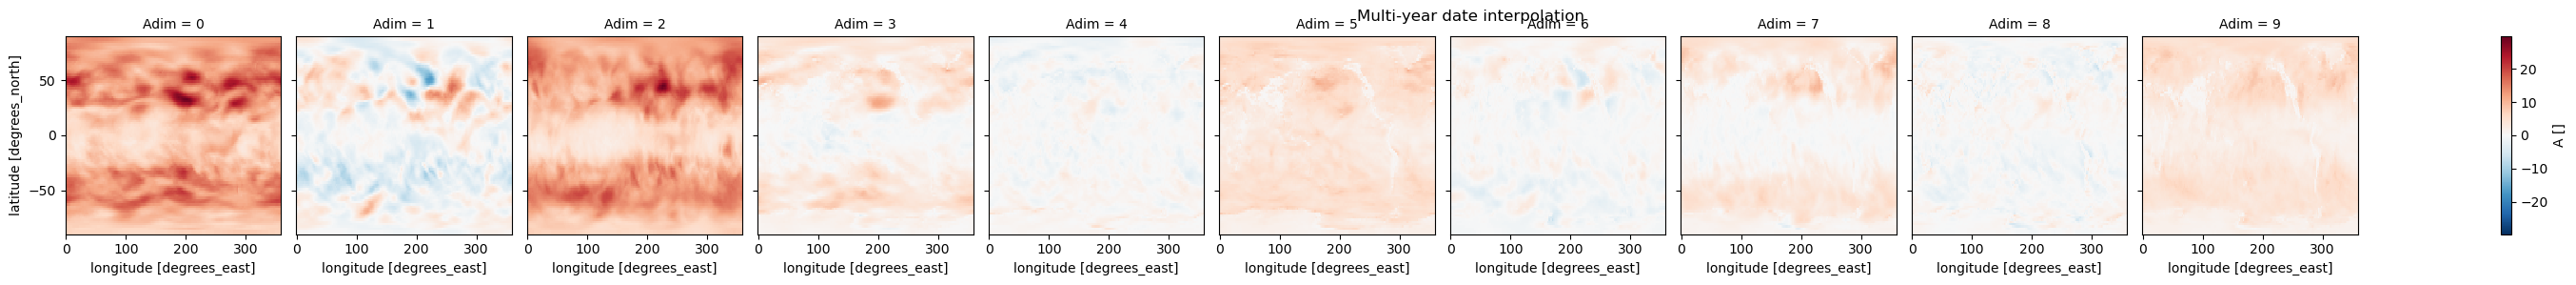

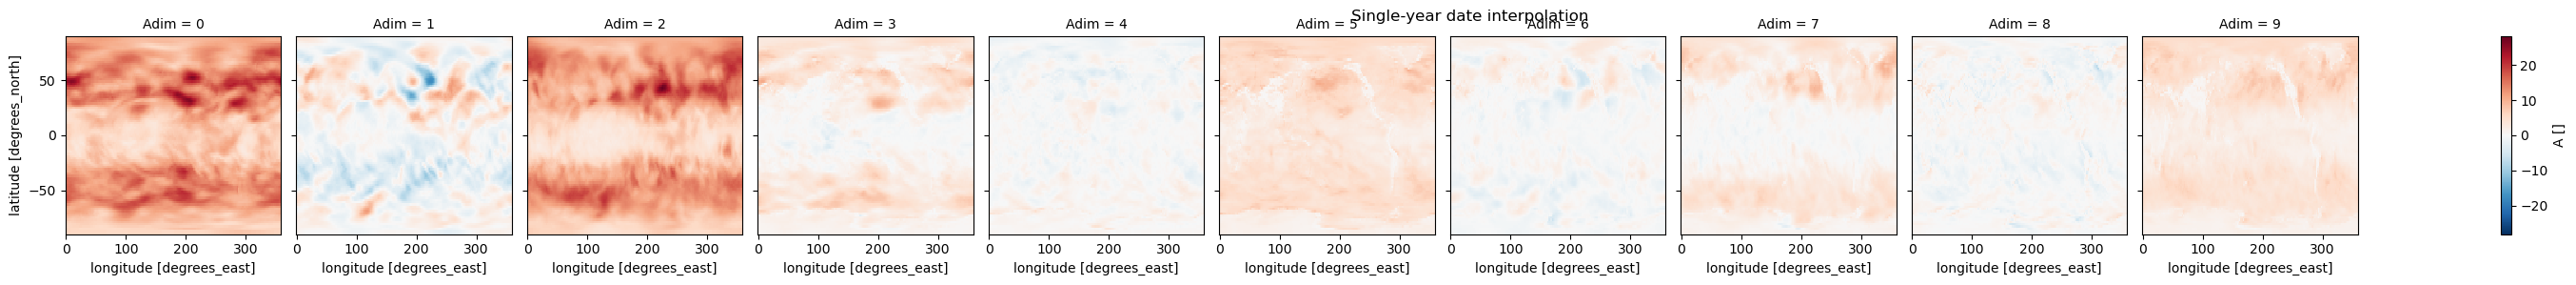

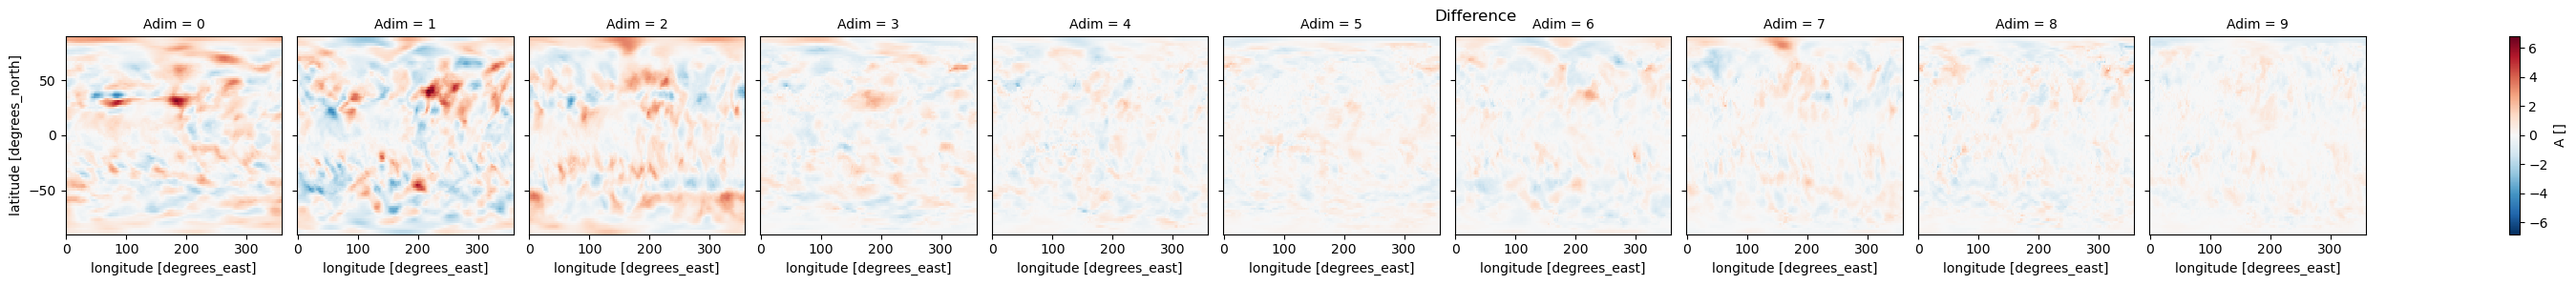

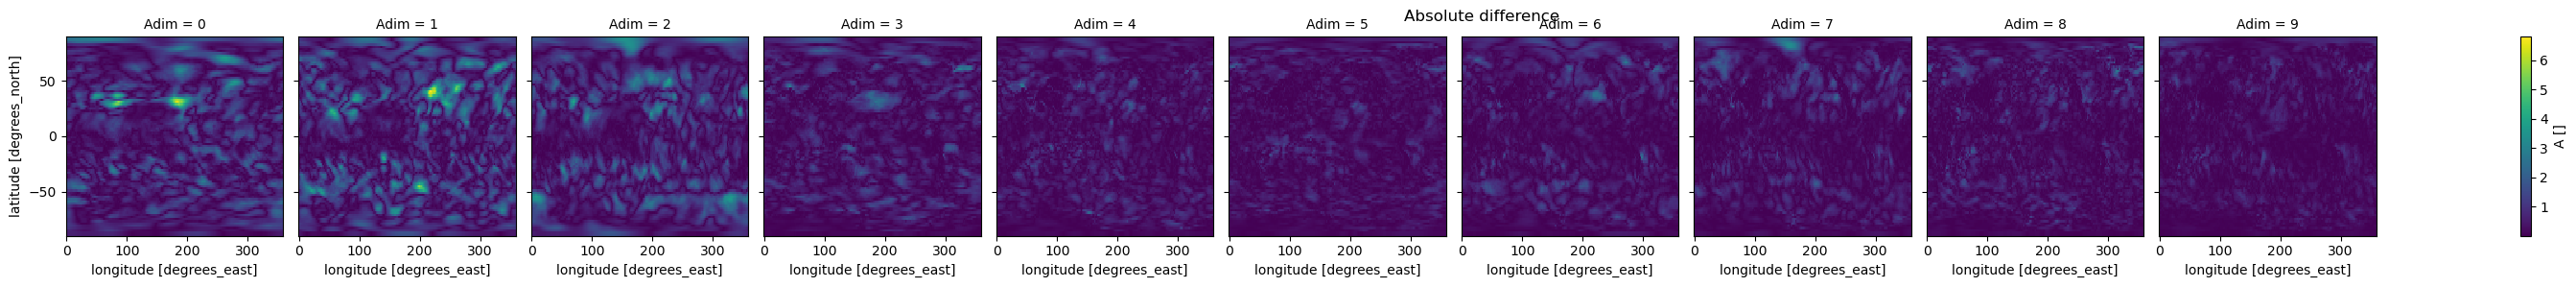

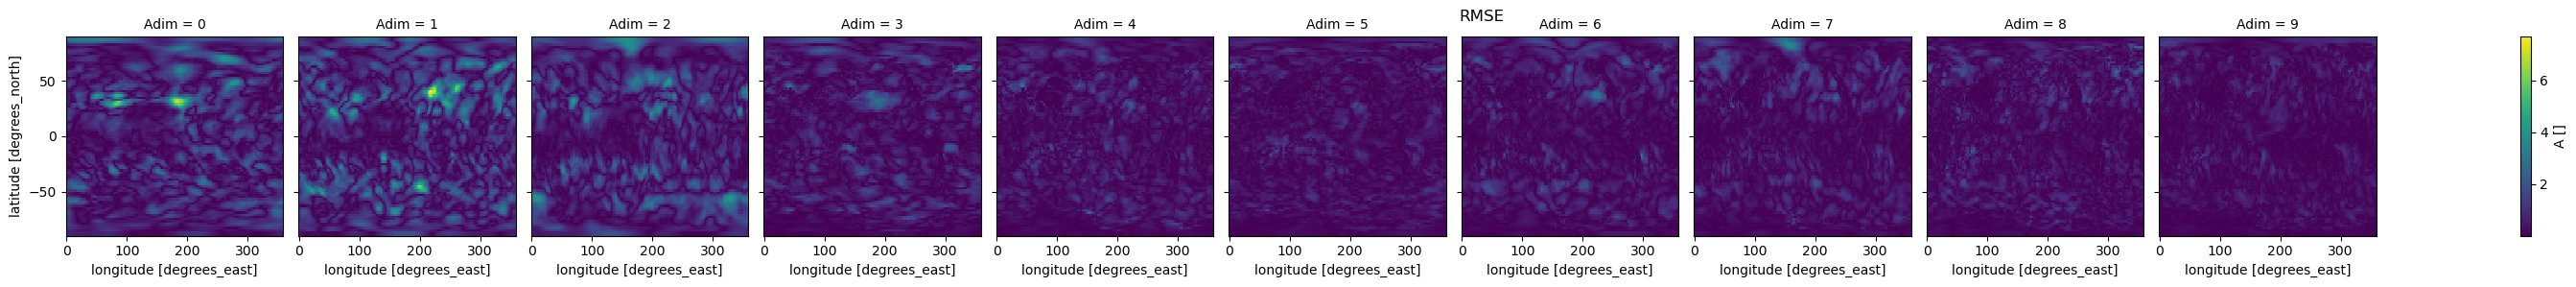

In [12]:
my.mean("days").A.plot(col = 'Adim')
plt.suptitle('Multi-year date interpolation')
plt.show()

sy.mean("days").A.plot(col = 'Adim')
plt.suptitle('Single-year date interpolation')
plt.show()


diff.mean("days").A.plot(col = 'Adim')
plt.suptitle('Difference')
plt.show()

np.abs(diff).mean("days").A.plot(col = 'Adim')
plt.suptitle('Absolute difference')
plt.show()


np.sqrt((diff ** 2).mean("days")).A.plot(col = 'Adim')
plt.suptitle('RMSE')
plt.show()


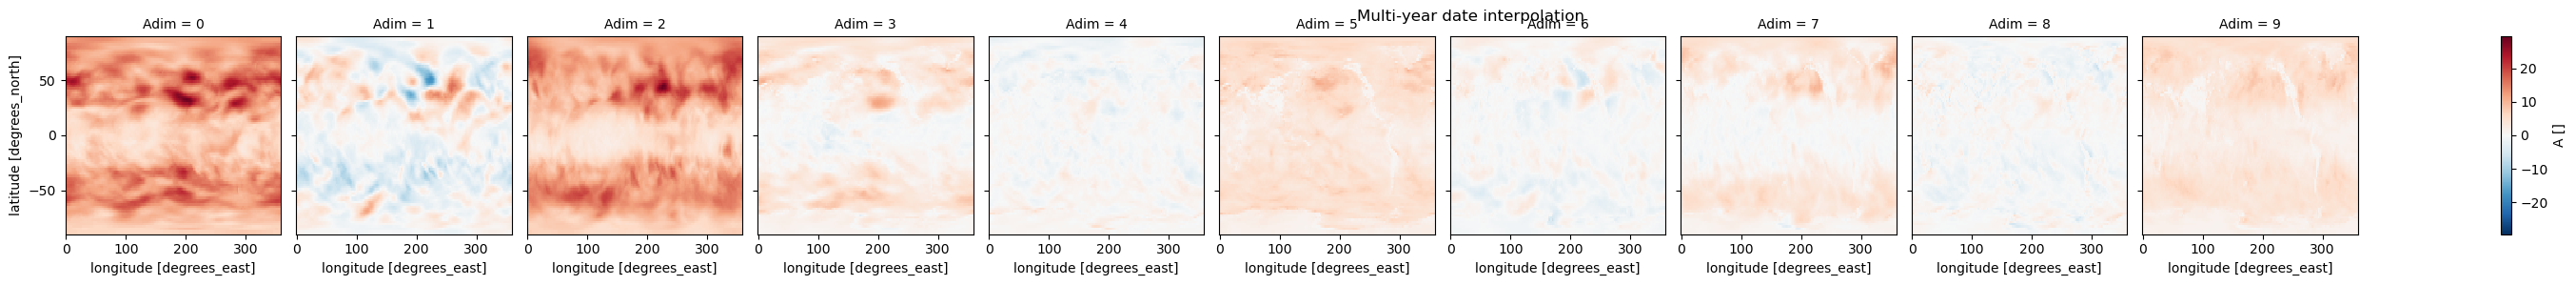

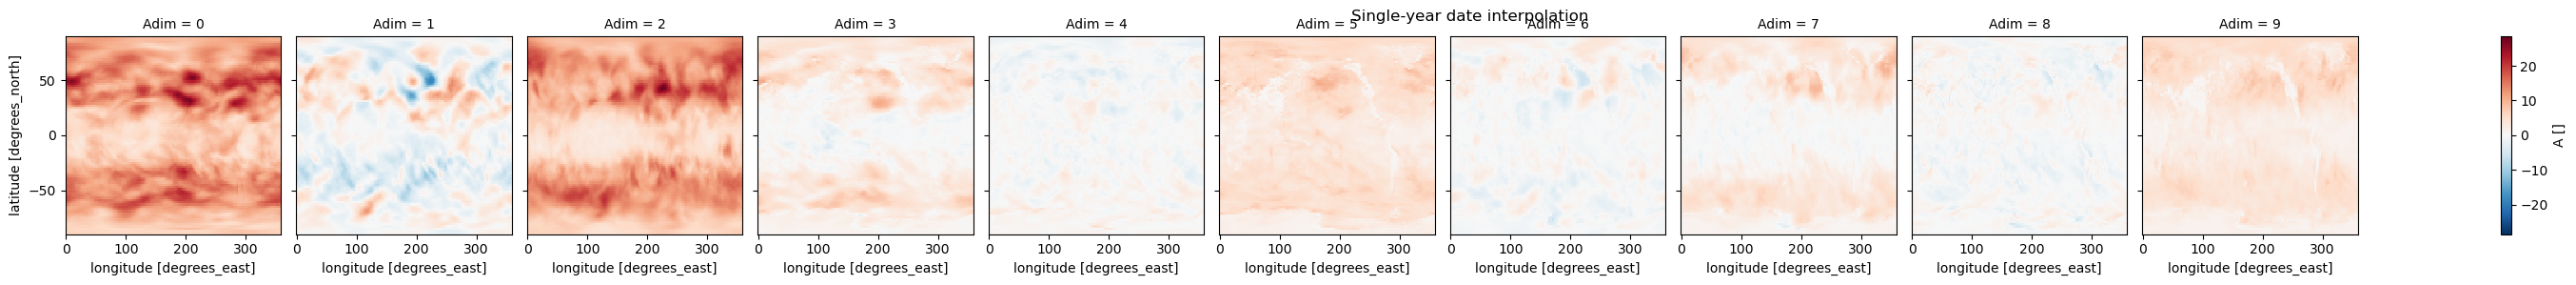

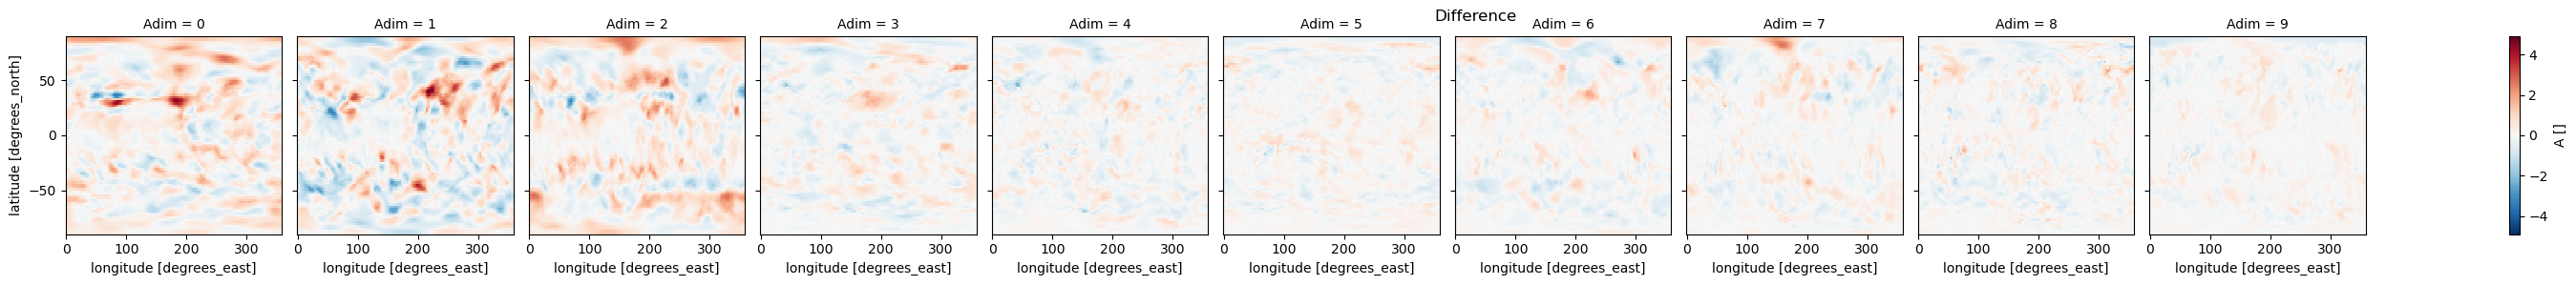

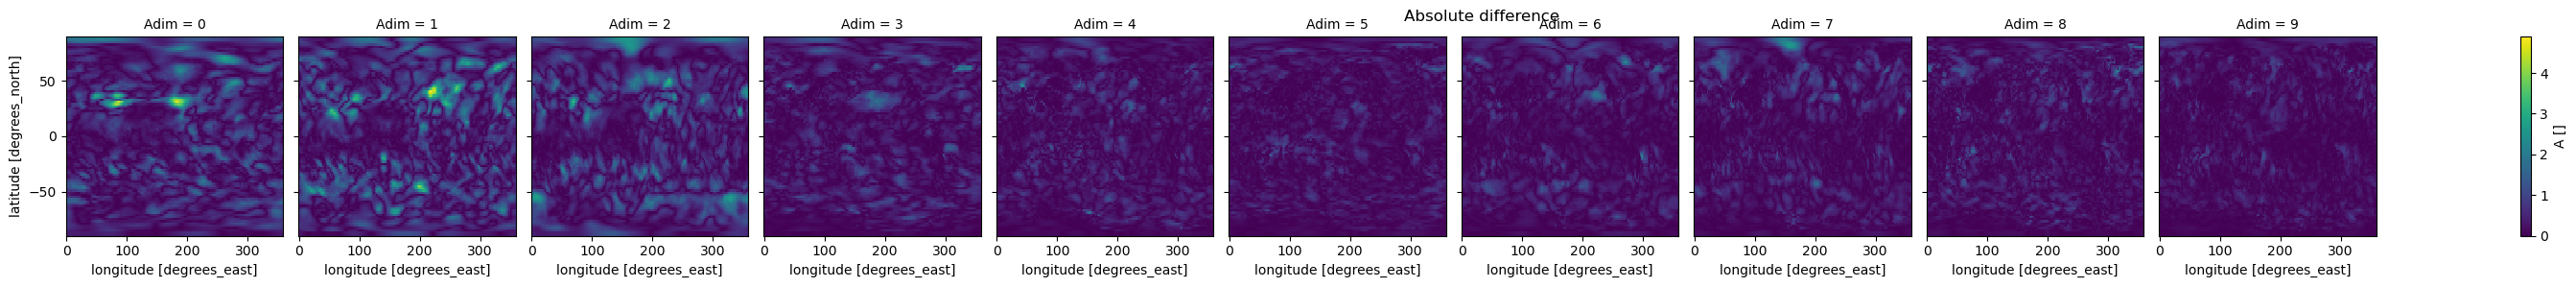

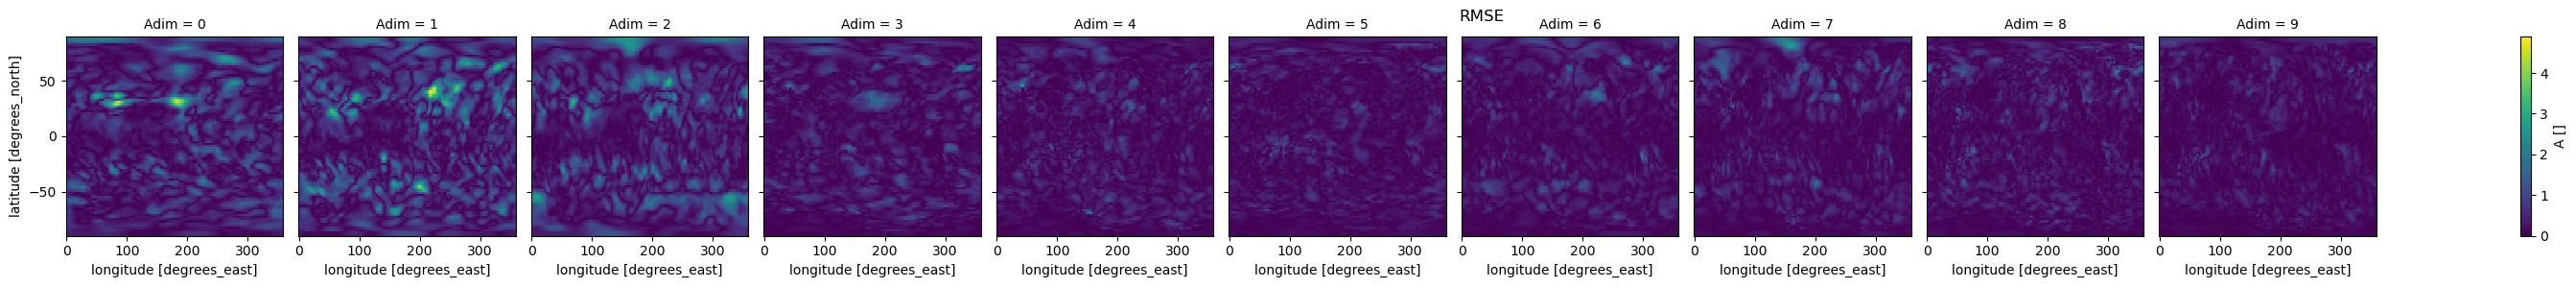

In [13]:
my.sel(days = 20).A.plot(col = 'Adim')
plt.suptitle('Multi-year date interpolation')
plt.show()

sy.sel(days = 20).A.plot(col = 'Adim')
plt.suptitle('Single-year date interpolation')
plt.show()


diff.sel(days = 20).A.plot(col = 'Adim')
plt.suptitle('Difference')
plt.show()

np.abs(diff).sel(days = 20).A.plot(col = 'Adim')
plt.suptitle('Absolute difference')
plt.show()


np.sqrt((diff ** 2)).sel(days = 20).A.plot(col = 'Adim')
plt.suptitle('RMSE')
plt.show()


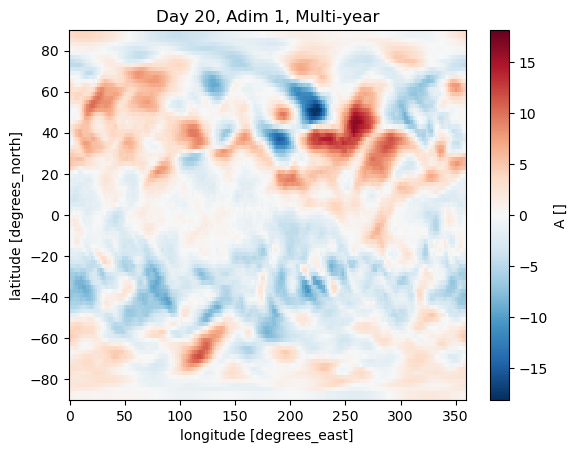

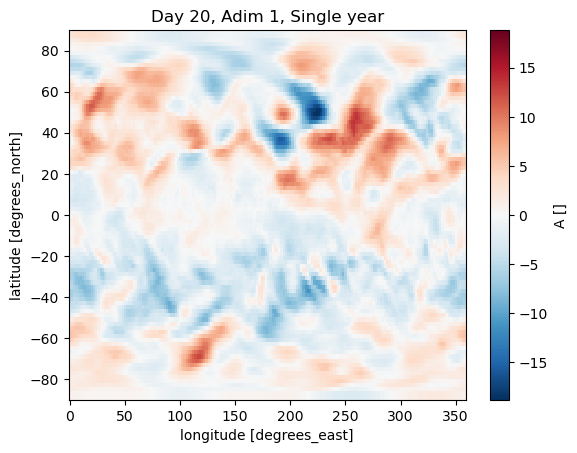

Text(0.5, 1.0, 'Difference, Day 20, Adim = 1')

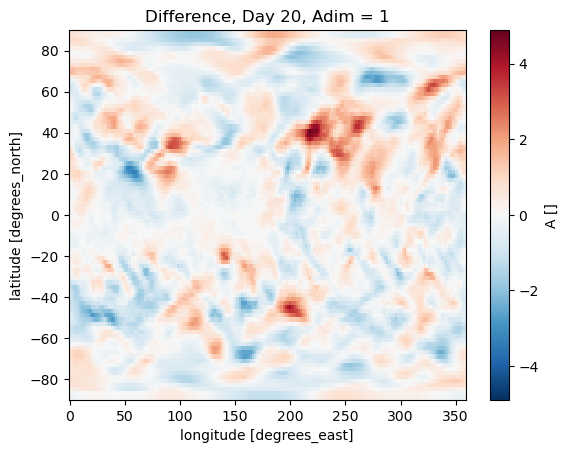

In [14]:
my.sel(days = 20).sel(Adim = 1).A.plot()
plt.title('Day 20, Adim 1, Multi-year')
plt.show()

sy.sel(days = 20).sel(Adim = 1).A.plot()
plt.title('Day 20, Adim 1, Single year')
plt.show()

diff.sel(days = 20, Adim = 1).A.plot()
plt.title('Difference, Day 20, Adim = 1')

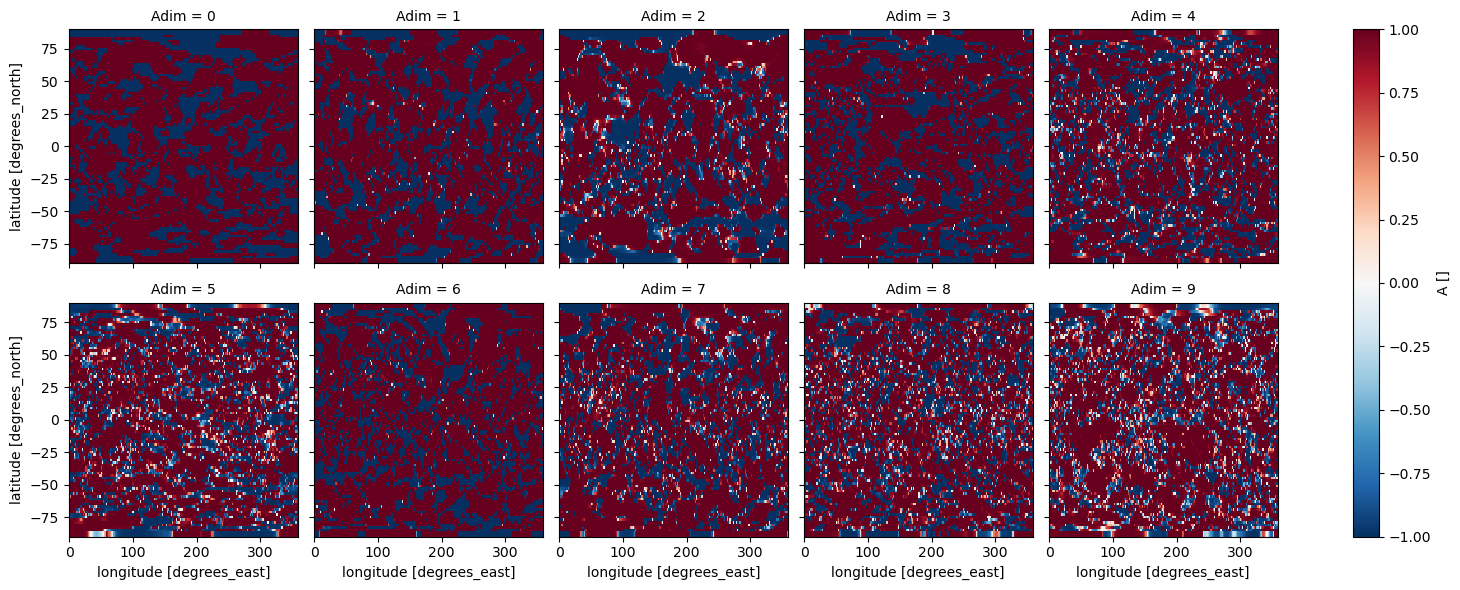

In [15]:
corr = xr.corr(sy.A, my.A, dim="days")
corr.plot(col = 'Adim', col_wrap = 5)


Text(0.5, 1.0, 'Correlation Single Year x Multi Year')

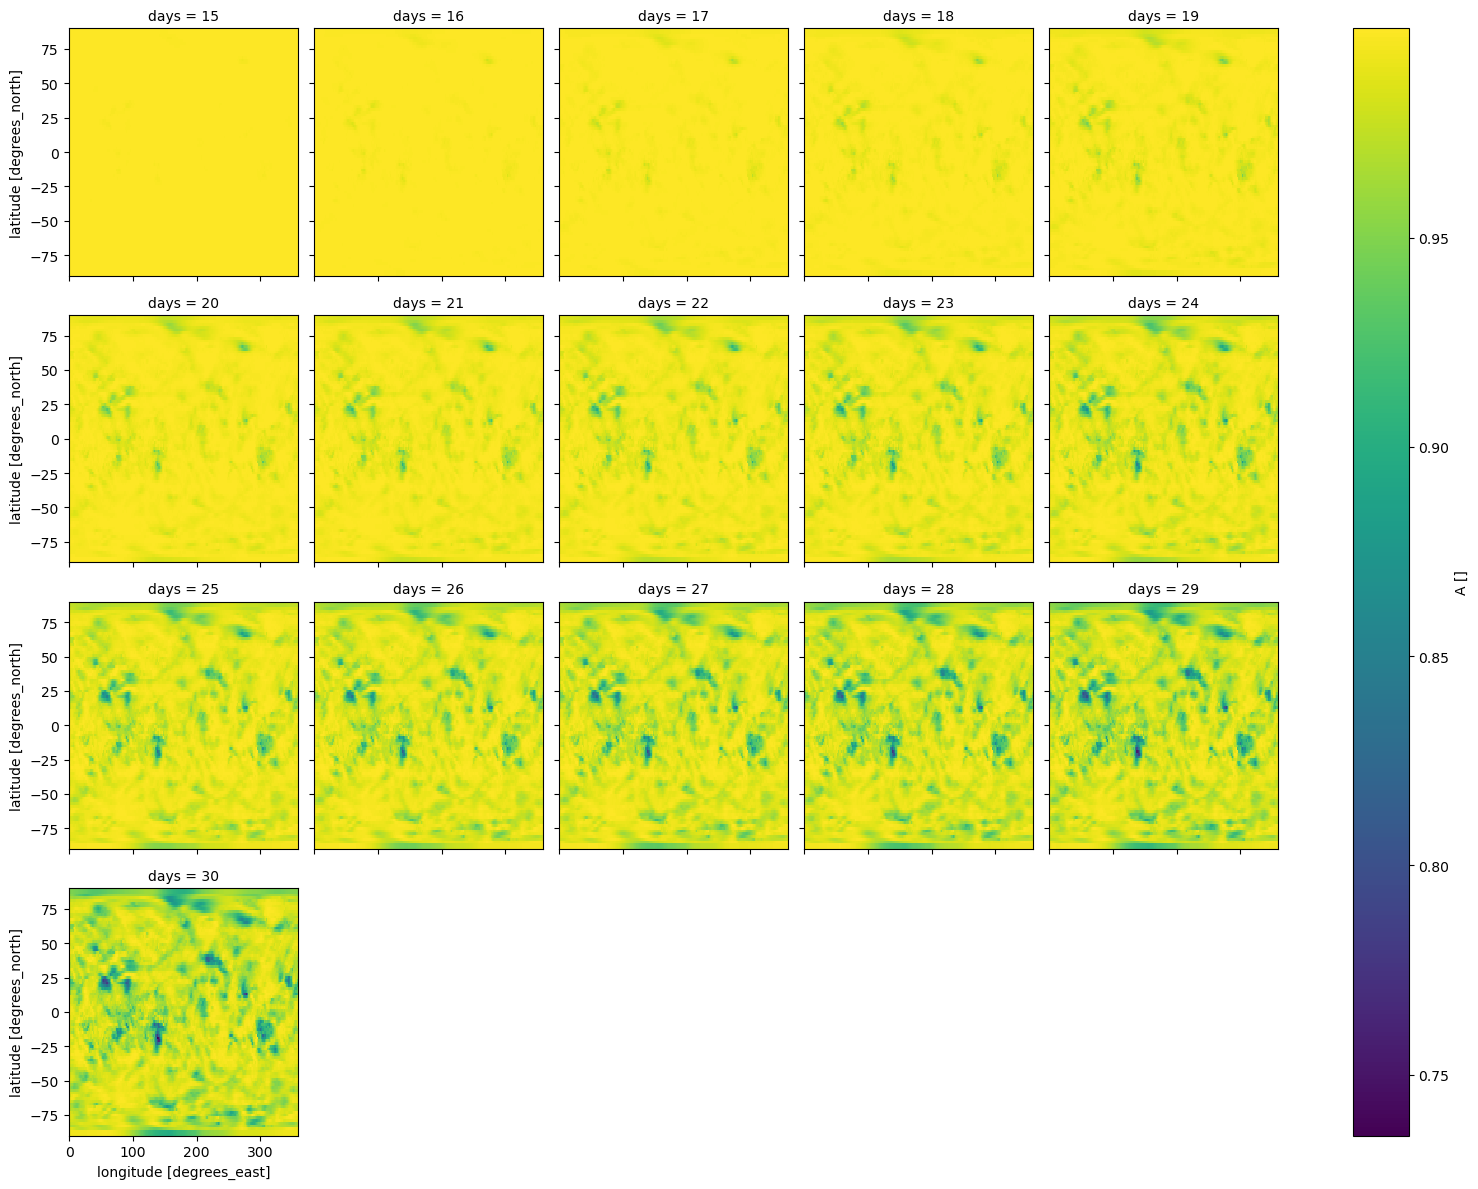

In [16]:
corr = xr.corr(sy.A, my.A, dim="Adim")
corr.plot(col = 'days', col_wrap = 5)
plt.title('Correlation Single Year x Multi Year')


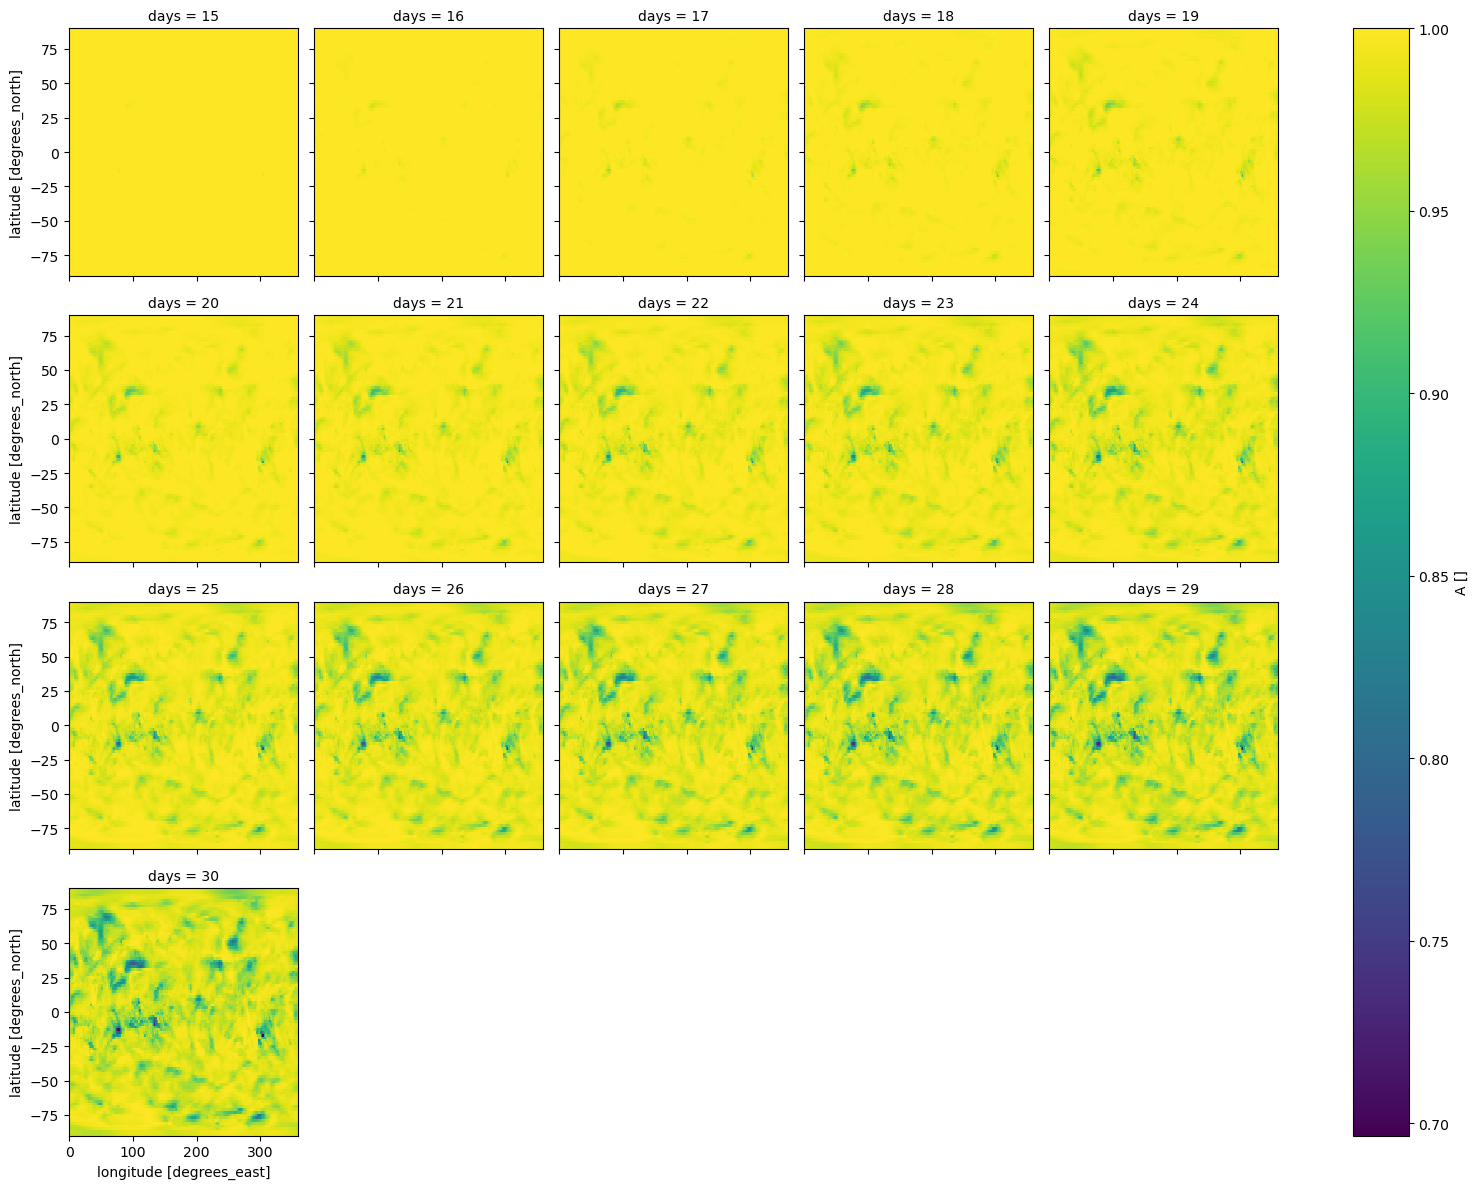

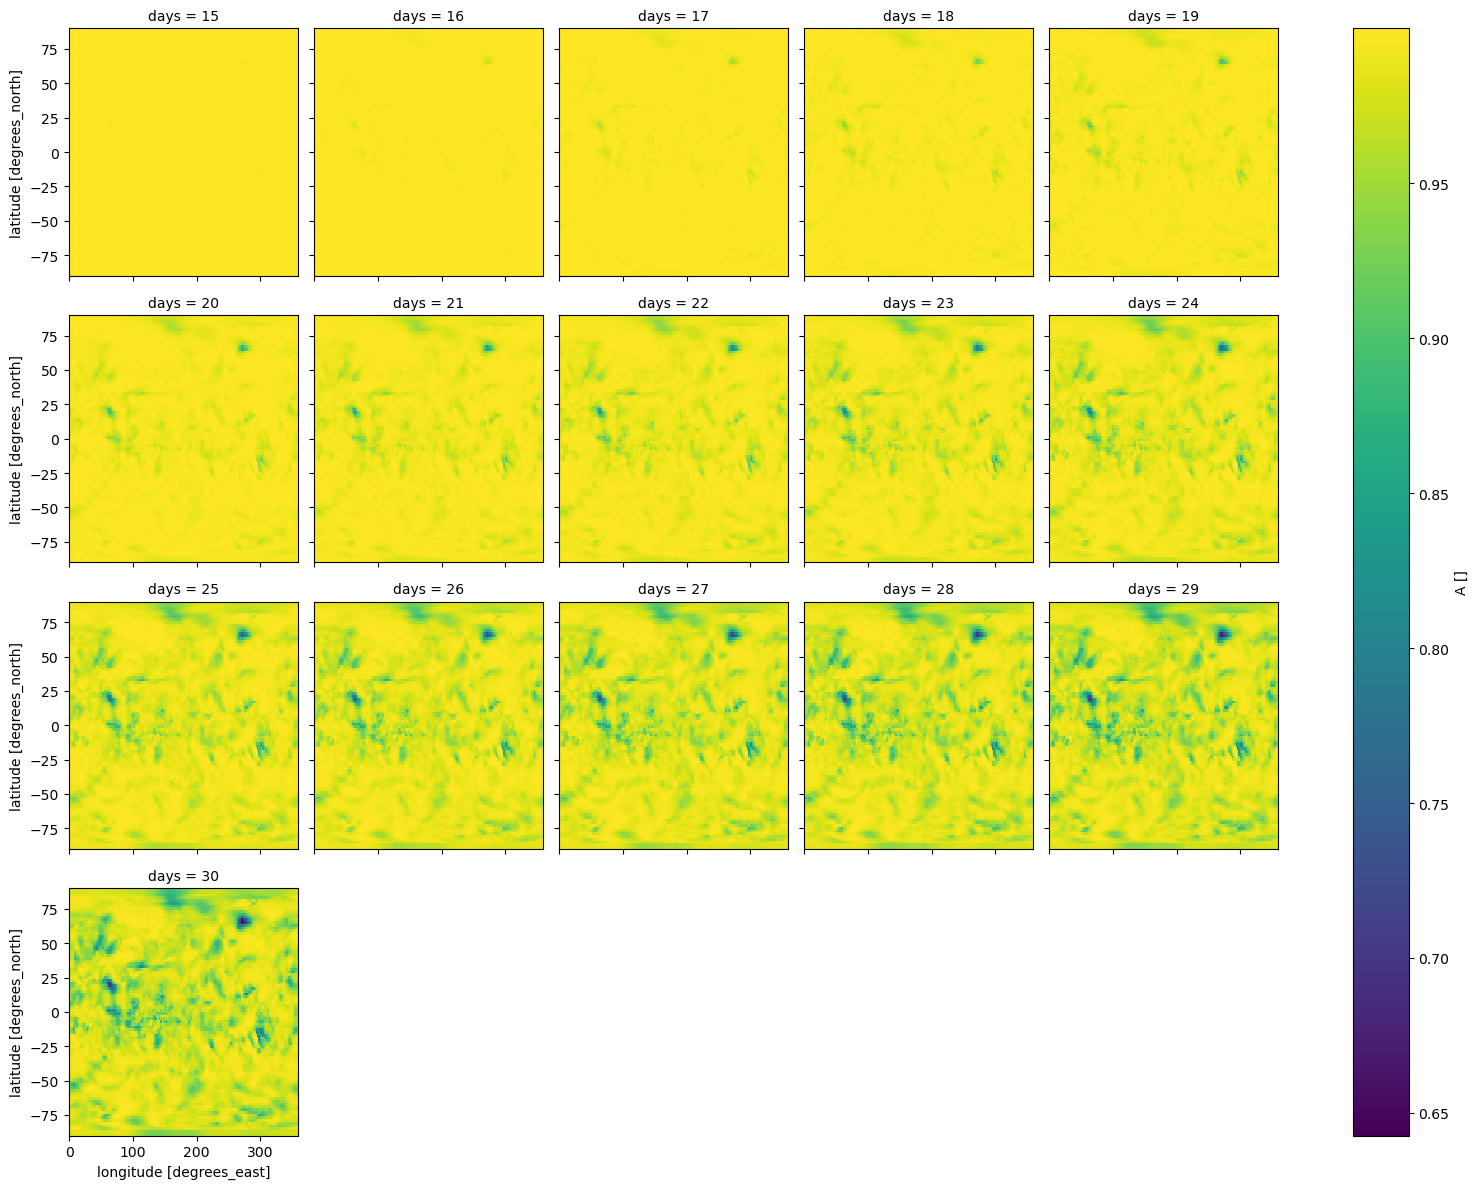

In [17]:
corr = xr.corr(sy.A, og.A, dim="Adim")
corr.plot(col = 'days', col_wrap = 5)
plt.title('Correlation Single Year x Original')

plt.show()

corr = xr.corr(my.A, og.A, dim="Adim")
corr.plot(col = 'days', col_wrap = 5)
plt.title('Correlation Multi Year x Original')

plt.show()

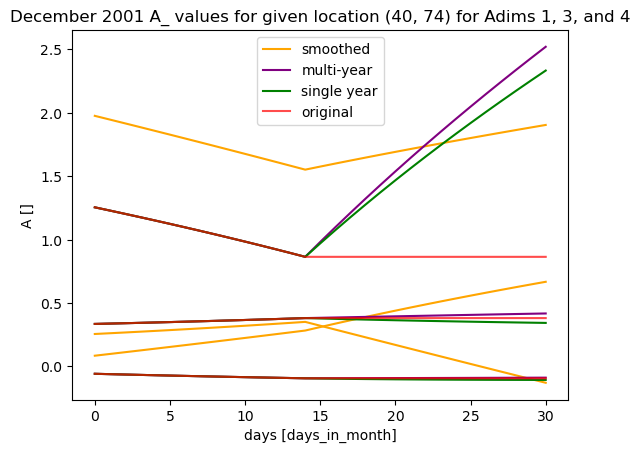

In [ ]:
original = dict_ds['v1_A_200112.nc']
multi_year = dict_ds['v2_A_200112.nc']
single_year = dict_ds['v3_A_200112.nc']
smoothed = dict_ds['v4_A_200112.nc']

lat = 40
lon = 74

#smoothed.sel(Adim = 1, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'orange', label = 'smoothed')#label="multi-year, Adim = 1")
multi_year.sel(Adim = 1, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'purple', label = 'multi-year')#label="multi-year, Adim = 1")
single_year.sel(Adim = 1, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'green', label = 'single year')#label="single-year, Adim = 1")
original.sel(Adim = 1, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'red',alpha = 0.7, label = 'original')#label="original, Adim = 1")

# multi_year.sel(Adim = 2, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'purple')#label="multi-year, Adim = 2")
# single_year.sel(Adim = 2, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'green')#label="single-year, Adim = 2")
# original.sel(Adim = 2, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'red', alpha = 0.7)#label="original, Adim = 2")

#smoothed.sel(Adim = 3, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'orange')
multi_year.sel(Adim = 3, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'purple')#label="multi-year, Adim = 3")
single_year.sel(Adim = 3, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'green')#label="single-year, Adim = 3")
original.sel(Adim = 3, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'red', alpha = 0.7)#label="original, Adim = 3")

#smoothed.sel(Adim = 4, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'orange')
multi_year.sel(Adim = 4, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'purple')#label="multi-year, Adim = 4")
single_year.sel(Adim = 4, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'green')#label="single-year, Adim = 4")
original.sel(Adim = 4, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'red', alpha = 0.7)#label="original, Adim = 4")

plt.title(f'December 2001 A_ values for given location ({lat}, {lon}) for Adims 1, 3, and 4')


plt.legend()
plt.show()

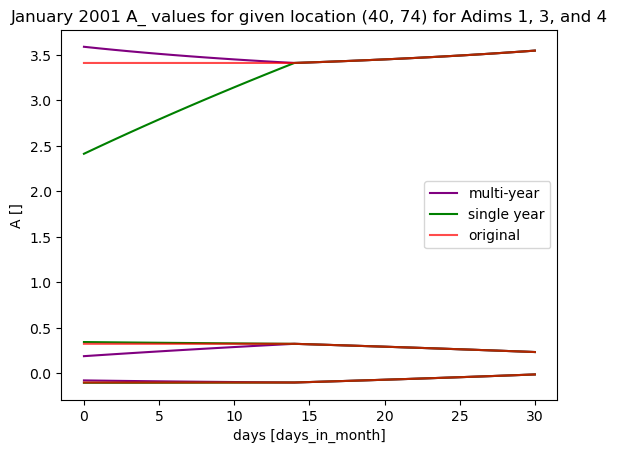

In [19]:
original = dict_ds['v1_A_200101.nc']
multi_year = dict_ds['v2_A_200101.nc']
single_year = dict_ds['v3_A_200101.nc']

lat = 40
lon = 74

multi_year.sel(Adim = 1, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'purple', label = 'multi-year')#label="multi-year, Adim = 1")
single_year.sel(Adim = 1, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'green', label = 'single year')#label="single-year, Adim = 1")
original.sel(Adim = 1, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'red',alpha = 0.7, label = 'original')#label="original, Adim = 1")

# multi_year.sel(Adim = 2, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'purple')#label="multi-year, Adim = 2")
# single_year.sel(Adim = 2, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'green')#label="single-year, Adim = 2")
# original.sel(Adim = 2, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'red', alpha = 0.7)#label="original, Adim = 2")

multi_year.sel(Adim = 3, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'purple')#label="multi-year, Adim = 3")
single_year.sel(Adim = 3, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'green')#label="single-year, Adim = 3")
original.sel(Adim = 3, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'red', alpha = 0.7)#label="original, Adim = 3")

multi_year.sel(Adim = 4, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'purple')#label="multi-year, Adim = 4")
single_year.sel(Adim = 4, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'green')#label="single-year, Adim = 4")
original.sel(Adim = 4, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'red', alpha = 0.7)#label="original, Adim = 4")


plt.title(f'January 2001 A_ values for given location ({lat}, {lon}) for Adims 1, 3, and 4')

plt.legend()
plt.show()

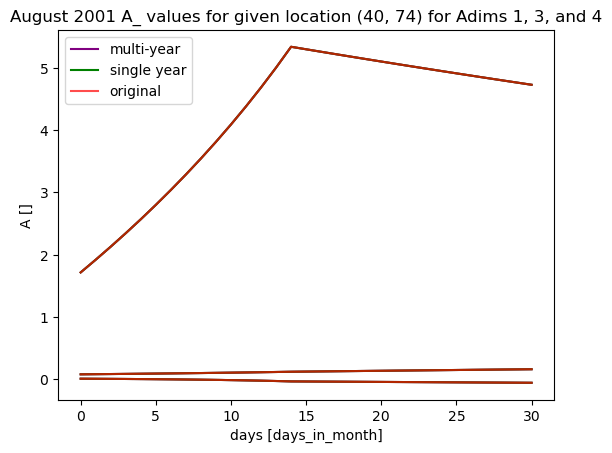

In [20]:
original = dict_ds['v1_A_200108.nc']
multi_year = dict_ds['v2_A_200108.nc']
single_year = dict_ds['v3_A_200108.nc']

lat = 40
lon = 74

multi_year.sel(Adim = 1, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'purple', label = 'multi-year')#label="multi-year, Adim = 1")
single_year.sel(Adim = 1, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'green', label = 'single year')#label="single-year, Adim = 1")
original.sel(Adim = 1, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'red',alpha = 0.7, label = 'original')#label="original, Adim = 1")

# multi_year.sel(Adim = 2, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'purple')#label="multi-year, Adim = 2")
# single_year.sel(Adim = 2, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'green')#label="single-year, Adim = 2")
# original.sel(Adim = 2, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'red', alpha = 0.7)#label="original, Adim = 2")

multi_year.sel(Adim = 3, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'purple')#label="multi-year, Adim = 3")
single_year.sel(Adim = 3, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'green')#label="single-year, Adim = 3")
original.sel(Adim = 3, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'red', alpha = 0.7)#label="original, Adim = 3")

multi_year.sel(Adim = 4, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'purple')#label="multi-year, Adim = 4")
single_year.sel(Adim = 4, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'green')#label="single-year, Adim = 4")
original.sel(Adim = 4, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'red', alpha = 0.7)#label="original, Adim = 4")


plt.title(f'August 2001 A_ values for given location ({lat}, {lon}) for Adims 1, 3, and 4')

plt.legend()
plt.show()

Could also add: 

- Distribution
    > ```
    > a.quantile(np.linspace(0, 1, 101), dim="time")'
    > b.quantile(np.linspace(0, 1, 101), dim="time")'
    > ```
- Temporal variability
    > ```
    > std_a = a.std("time")
    > std_b = b.std("time")
    > std_difference = std_a - std_b
    > ```

- Temporal extremes
    > ```
    > max_a = a.max("time")
    > max_b = b.max("time")
    > min_a = a.min("time")
    > min_b = b.min("time")
    > ```


In [ ]:
## slice from 15-30 is the most different, should be the same from 1, 14
#multi_year.sel(days = slice(15, 30))
#single_year.sel(days = slice(15, 30))

#multi_year.sel(days = slice(0,14))
#single_year.sel(days = slice(0, 14))



In [ ]:
multi_year.days.max()

<xarray.DataArray 'days' ()> Size: 4B
array(30, dtype=int32)
Attributes:
    units:    days_in_month

### Comparing January Interpolation

In [ ]:
iy = 2000
im = 12
jan_orig = xr.open_dataset(gv.pre_path+'testing/'+'A_'+int2str(iy,4)+int2str(im,2)+'.nc')
jan_orig

<xarray.Dataset> Size: 20MB
Dimensions:    (Adim: 10, days: 31, latitude: 90, longitude: 180)
Coordinates:
  * Adim       (Adim) int32 40B 0 1 2 3 4 5 6 7 8 9
  * days       (days) int32 124B 0 1 2 3 4 5 6 7 8 ... 23 24 25 26 27 28 29 30
  * latitude   (latitude) float32 360B -89.0 -87.0 -85.0 ... 85.0 87.0 89.0
  * longitude  (longitude) float32 720B 0.0 2.0 4.0 6.0 ... 354.0 356.0 358.0
Data variables:
    A          (Adim, days, latitude, longitude) float32 20MB ...

In [ ]:
np.unique(jan_orig.A[0][5]-jan_orig.A[0][10])

array([-1.966299 , -1.9653702, -1.9455204, ...,  2.8789616,  2.9617987,
        3.0095072], shape=(15797,), dtype=float32)

In [ ]:
np.unique(jan_orig.A[0][15]-jan_orig.A[0][20])

array([-4.1343803, -4.1340313, -4.085541 , ...,  5.336912 ,  5.5110064,
        5.5804796], shape=(15822,), dtype=float32)

In [ ]:
# dateInput = 
# fileInput = 
# fileInput_yr = fileInput
# fileINput_preYr = 
# fileInput_nextYr = 


# original = date_interpolation(dateInput, fileInput)
# same_year = date_interpolation_sameyear(dateInput, fileInput)
# multi_year = date_interpolation_multiyear(dateInput, fileInput_yr, fileInput_preYr, fileInput_nextYr)




In [ ]:
iy = 2000
im = 2
iday = 20


iy = 2000
filename = gv.pre_path+ 'Cov1_'+int2str(iy,4)+'.nc'
nc = Dataset(filename,'r',format='NETCDF4')
#nc = Dataset(filename,'r',format='NETCDF3_CLASSIC')
xllon = nc.variables['longitude'][:]
xllat = nc.variables['latitude'][:]
var = ['u200p','v200p','u850p','v850p']
cov = {}
for iv in range(len(var)):
    for iiv in range(iv,len(var),1):
        vname = var[iv]+var[iiv]
        cov[vname] = nc.variables[vname][:,:,:]
        cov[vname][:,0,:] = cov[vname][:,1,:]
        cov[vname][:,-1,:] = cov[vname][:,-2,:]
nc.close()

test20 = date_interpolation(datetime(iy, im, 20, 0,0), cov['u200pu200p'], timing = True)
test21 = date_interpolation(datetime(iy, im, 21, 0,0), cov['u200pu200p'], timing = True)


Original date interpolation run time: 0.00
Original date interpolation run time: 0.00


In [ ]:
test20[0].data[0:20]


array([24.69307827, 24.44794806, 24.2001131 , 23.96457646, 23.74753689,
       23.56317849, 23.41728079, 23.31311482, 23.24953474, 23.23069145,
       23.25099708, 23.31532432, 23.41778433, 23.54641408, 23.69471859,
       23.8555411 , 24.02301525, 24.19927755, 24.38947073, 24.60099187])

In [ ]:
test21[0].data[0:20]

array([25.83583325, 25.53436194, 25.22931533, 24.93696792, 24.66398877,
       24.4242536 , 24.22299036, 24.06337626, 23.94512269, 23.87367498,
       23.84539663, 23.86631643, 23.93145403, 24.02899821, 24.15144032,
       24.29023269, 24.43765325, 24.59352072, 24.76141509, 24.94757041])

In [ ]:
## FROM: def run_calA() in calA.py



im = 12
nday = monthrange(iy, im)[1]

cov2d = {}

for iv in range(len(var)):
    for iiv in range(iv,len(var),1):
        vname = var[iv]+var[iiv]
        vname1 = var[iv]+var[iiv]
        print(vname1)
        cov2d[vname1] = np.dstack([date_interpolation(datetime(iy,im,iday,0,0),cov[vname1]) for iday in range(1,nday+1,1)])


u200pu200p
u200pv200p
u200pu850p
u200pv850p
v200pv200p
v200pu850p
v200pv850p
u850pu850p
u850pv850p
v850pv850p


In [ ]:


for iy in range(gv.Year1, gv.Year2+1):
    filename = gv.pre_path+ 'Cov1_'+int2str(iy,4)+'.nc'

    nc = Dataset(filename,'r',format='NETCDF4')
    #nc = Dataset(filename,'r',format='NETCDF3_CLASSIC')
    xllon = nc.variables['longitude'][:]
    xllat = nc.variables['latitude'][:]
    var = ['u200p','v200p','u850p','v850p']
    cov = {}
    for iv in range(len(var)):
        for iiv in range(iv,len(var),1):
            vname = var[iv]+var[iiv]
            cov[vname] = nc.variables[vname][:,:,:]
            cov[vname][:,0,:] = cov[vname][:,1,:]
            cov[vname][:,-1,:] = cov[vname][:,-2,:]
    nc.close()
    ### FOR IMPORTING PRE/POST YEARS 
    # ########## CYL
    # if iy > gv.Year1
    #         filename_preY = gv.pre_path+ 'Cov1_'+int2str(iy-1,4)+'.nc'
    #         ncpre = Dataset(filename_preY,'r',format='NETCDF4')
    #         read cov01
    #     else:
    #         cov01 = None
    #     if iy < gv.Year2:
    #         filename_aftY = gv.pre_path+ 'Cov1_'+int2str(iy+1,4)+'.nc'
    #         read cov12
    #     else
    #         cov12 = None
    # ########## CYL

   
    # for iv in range(len(var)):
    #     for iiv in range (iv, len(var), 1):
    #         print(iv)

    #for im in range(1,13,1):
        # nday = monthrange(iy,im)[1]
        # ### for each month has one F, this is where the randomness from
        # cov2d = {}
  


['u200p', 'v200p', 'u850p', 'v850p']
['u200p', 'v200p', 'u850p', 'v850p']
['u200p', 'v200p', 'u850p', 'v850p']
['u200p', 'v200p', 'u850p', 'v850p']
['u200p', 'v200p', 'u850p', 'v850p']
['u200p', 'v200p', 'u850p', 'v850p']
['u200p', 'v200p', 'u850p', 'v850p']
['u200p', 'v200p', 'u850p', 'v850p']
['u200p', 'v200p', 'u850p', 'v850p']
['u200p', 'v200p', 'u850p', 'v850p']


In [ ]:
cov2d.keys()

dict_keys(['u200pu200p', 'u200pv200p', 'u200pu850p', 'u200pv850p', 'v200pv200p', 'v200pu850p', 'v200pv850p', 'u850pu850p', 'u850pv850p', 'v850pv850p'])

array([0.], dtype=float32)

In [ ]:
for iy in range(2000, 2001):
#for iy in range(gv.Year1, gv.Year2+1):
    #print(iy)
    filename = gv.pre_path+ 'Cov1_'+int2str(iy,4)+'.nc'
    nc = Dataset(filename,'r',format='NETCDF4')
    #nc = Dataset(filename,'r',format='NETCDF3_CLASSIC')
    xllon = nc.variables['longitude'][:]
    xllat = nc.variables['latitude'][:]
    var = ['u200p','v200p','u850p','v850p']
    cov = {}
    for iv in range(len(var)):
        for iiv in range(iv,len(var),1):
            vname = var[iv]+var[iiv]
            cov[vname] = nc.variables[vname][:,:,:]
            cov[vname][:,0,:] = cov[vname][:,1,:]
            cov[vname][:,-1,:] = cov[vname][:,-2,:]
    nc.close()

    for im in range(1,13,1):
                time1 = time.time()
                nday = monthrange(iy,im)[1]
                ### for each month has one F, this is where the randomness from
                cov2d = {}
                for iv in range(len(var)):
                    for iiv in range(iv,len(var),1):
                        vname = var[iv]+var[iiv]
                        vname1 = var[iv]+var[iiv]
                        cov2d[vname1] = np.dstack([date_interpolation(datetime(iy,im,iday,0,0),cov[vname1]) for iday in range(1,nday+1,1)])
    
                time1 = time.time()
    
                ## can't directly call a dictionary key
                #a = np.array(cov2d[cov2d.keys()[0]].shape).tolist()
                a = np.array(cov2d[list(cov2d.keys())[0]].shape).tolist()
                covm2d = np.zeros([10]+a)
                count1 = 0
                for iv in range(len(var)):
                    for iiv in range(iv,len(var),1):
                        vname = var[iv]+var[iiv]
                        covm2d[count1,:,:,:] = cov2d[vname][:,:,:]
                        count1 += 1
    
                covv = np.zeros([4,4]+a)
                covv[0,:,:,:,:] = covm2d[0:4,:,:,:]
                covv[:,0,:,:,:] = covm2d[0:4,:,:,:]
                covv[1,1:,:,:,:] = covm2d[4:7,:,:,:]
                covv[1:,1,:,:,:] = covm2d[4:7,:,:,:]
                covv[2,2:,:,:,:] = covm2d[7:9,:,:,:]
                covv[2:,2,:,:,:] = covm2d[7:9,:,:,:]
                covv[3,3,:,:,:] = covm2d[9,:,:,:]
                #print 'finish interp cov data', time.time()-time1
                time1 = time.time()
    
                A = np.zeros(covv.shape)
                A1 = np.zeros([10]+a)
                count = 0
                for iday in range(nday):
                    for ixx in range(xllon.shape[0]):
                        for iyy in range(xllat.shape[0]):
                            if np.isnan(covv[:,:,iyy,ixx,iday]).any():
                                ## TODO: if needed add break count? 
                                #print('break')
                                break
                            A[:,:,iyy,ixx,iday] = linalg.cholesky(covv[:,:,iyy,ixx,iday]).T
    
                A1[0,:,:,:] = A[0,0,:,:,:]
                A1[1,:,:,:] = A[1,0,:,:,:]
                A1[2,:,:,:] = A[1,1,:,:,:]
                A1[3,:,:,:] = A[2,0,:,:,:]
                A1[4,:,:,:] = A[2,1,:,:,:]
                A1[5,:,:,:] = A[2,2,:,:,:]
                A1[6,:,:,:] = A[3,0,:,:,:]
                A1[7,:,:,:] = A[3,1,:,:,:]
                A1[8,:,:,:] = A[3,2,:,:,:]
                A1[9,:,:,:] = A[3,3,:,:,:]
                #print 'finish cal A data', time.time()-time1
                time1 = time.time()

2000


In [ ]:
cov

{'u200pu200p': masked_array(
   data=[[[ 23.34344 ,  24.295376,  25.311352, ...,  20.917381,
            21.65352 ,  22.463703],
          [ 23.34344 ,  24.295376,  25.311352, ...,  20.917381,
            21.65352 ,  22.463703],
          [ 26.819315,  28.157799,  29.503838, ...,  22.855186,
            24.18196 ,  25.500118],
          ...,
          [ 48.1266  ,  47.407536,  46.994644, ...,  51.42572 ,
            50.197193,  49.08365 ],
          [ 56.882294,  57.051243,  57.421276, ...,  57.56672 ,
            57.15376 ,  56.92078 ],
          [ 56.882294,  57.051243,  57.421276, ...,  57.56672 ,
            57.15376 ,  56.92078 ]],
 
         [[ 19.32472 ,  19.933657,  20.575705, ...,  17.666824,
            18.188828,  18.747328],
          [ 19.32472 ,  19.933657,  20.575705, ...,  17.666824,
            18.188828,  18.747328],
          [ 13.001537,  13.117481,  13.316236, ...,  13.036505,
            12.975982,  12.962833],
          ...,
          [ 46.015507,  48.482582,  50

In [ ]:
def createNetCDF(A1,iy,im,xllon,xllat):
	"""
	crerate NetCDF file for the syn wind, it will be 124MB each
	"""
	nc = Dataset(gv.pre_path+'A_'+int2str(iy,4)+int2str(im,2)+'.nc','w',format='NETCDF4')
	#nc = Dataset(gv.pre_path+'A_'+int2str(iy,4)+int2str(im,2)+'.nc','w',format='NETCDF3_CLASSIC')
	nc.createDimension('latitude',xllat.shape[0])
	nc.createDimension('longitude',xllon.shape[0])
	nc.createDimension('days',A1.shape[3])
	nc.createDimension('Adim',A1.shape[0])
	lats = nc.createVariable('latitude',np.dtype('float32').char,('latitude',))
	lons = nc.createVariable('longitude',np.dtype('float32').char,('longitude',))
	days = nc.createVariable('days',np.dtype('int32').char,('days',))
	Adim = nc.createVariable('Adim',np.dtype('int32').char,('Adim',))
	lats.units = 'degrees_north'
	lons.units = 'degrees_east'
	days.units = 'days_in_month'
	Adim.units = 'dimensions_in_A'
	lats[:] = xllat
	lons[:] = xllon
	days[:] = range(0,A1.shape[3],1)
	Adim[:] = range(0,A1.shape[0],1)
	AA = nc.createVariable('A',np.dtype('float32').char,('Adim','days','latitude','longitude'))
	AA.units = ''
	AA[:] = np.rollaxis(A1,3,1)
	nc.close()
	return()

def run_calA():
	for iy in range(gv.Year1, gv.Year2+1):
		filename = gv.pre_path+ 'Cov1_'+int2str(iy,4)+'.nc'
		nc = Dataset(filename,'r',format='NETCDF4')
		#nc = Dataset(filename,'r',format='NETCDF3_CLASSIC')
		xllon = nc.variables['longitude'][:]
		xllat = nc.variables['latitude'][:]
		var = ['u200p','v200p','u850p','v850p']
		cov = {}
		for iv in range(len(var)):
			for iiv in range(iv,len(var),1):
				vname = var[iv]+var[iiv]
				cov[vname] = nc.variables[vname][:,:,:]
				cov[vname][:,0,:] = cov[vname][:,1,:]
				cov[vname][:,-1,:] = cov[vname][:,-2,:]
		nc.close()

		for im in range(1,13,1):
			time1 = time.time()
			nday = monthrange(iy,im)[1]
			### for each month has one F, this is where the randomness from
			cov2d = {}
			for iv in range(len(var)):
				for iiv in range(iv,len(var),1):
					vname = var[iv]+var[iiv]
					vname1 = var[iv]+var[iiv]
					cov2d[vname1] = np.dstack([date_interpolation(datetime(iy,im,iday,0,0),cov[vname1]) for iday in range(1,nday+1,1)])

			time1 = time.time()

			## can't directly call a dictionary key
			#a = np.array(cov2d[cov2d.keys()[0]].shape).tolist()
			a = np.array(cov2d[list(cov2d.keys())[0]].shape).tolist()
			covm2d = np.zeros([10]+a)
			count1 = 0
			for iv in range(len(var)):
				for iiv in range(iv,len(var),1):
					vname = var[iv]+var[iiv]
					covm2d[count1,:,:,:] = cov2d[vname][:,:,:]
					count1 += 1

			covv = np.zeros([4,4]+a)
			covv[0,:,:,:,:] = covm2d[0:4,:,:,:]
			covv[:,0,:,:,:] = covm2d[0:4,:,:,:]
			covv[1,1:,:,:,:] = covm2d[4:7,:,:,:]
			covv[1:,1,:,:,:] = covm2d[4:7,:,:,:]
			covv[2,2:,:,:,:] = covm2d[7:9,:,:,:]
			covv[2:,2,:,:,:] = covm2d[7:9,:,:,:]
			covv[3,3,:,:,:] = covm2d[9,:,:,:]
			#print 'finish interp cov data', time.time()-time1
			time1 = time.time()

			A = np.zeros(covv.shape)
			A1 = np.zeros([10]+a)
			count = 0
			for iday in range(nday):
				for ixx in range(xllon.shape[0]):
					for iyy in range(xllat.shape[0]):
						if np.isnan(covv[:,:,iyy,ixx,iday]).any():
							## TODO: if needed add break count? 
							#print('break')
							break
						A[:,:,iyy,ixx,iday] = linalg.cholesky(covv[:,:,iyy,ixx,iday]).T

			A1[0,:,:,:] = A[0,0,:,:,:]
			A1[1,:,:,:] = A[1,0,:,:,:]
			A1[2,:,:,:] = A[1,1,:,:,:]
			A1[3,:,:,:] = A[2,0,:,:,:]
			A1[4,:,:,:] = A[2,1,:,:,:]
			A1[5,:,:,:] = A[2,2,:,:,:]
			A1[6,:,:,:] = A[3,0,:,:,:]
			A1[7,:,:,:] = A[3,1,:,:,:]
			A1[8,:,:,:] = A[3,2,:,:,:]
			A1[9,:,:,:] = A[3,3,:,:,:]
			#print 'finish cal A data', time.time()-time1
			time1 = time.time()
			createNetCDF(A1,iy,im,xllon,xllat)
			#print 'finish saving A data', time.time()-time1
			gc.collect()
	return()


In [14]:
date_interp_version = 'v3'

#iy = 2001
for iy in range(gv.Year1, gv.Year2+1):
#for iy in [2001]:
    filename = gv.pre_path+ 'Cov1_'+int2str(iy,4)+'.nc'

    nc = Dataset(filename,'r',format='NETCDF4')
    #nc = Dataset(filename,'r',format='NETCDF3_CLASSIC')
    xllon = nc.variables['longitude'][:]
    xllat = nc.variables['latitude'][:]
    var = ['u200p','v200p','u850p','v850p']
    cov = {}
    for iv in range(len(var)):
        for iiv in range(iv,len(var),1):
            vname = var[iv]+var[iiv]
            cov[vname] = nc.variables[vname][:,:,:]
            cov[vname][:,0,:] = cov[vname][:,1,:]
            cov[vname][:,-1,:] = cov[vname][:,-2,:]
    nc.close()

    ## if multi-year analysis, need data for previous and following year 
    if date_interp_version == 'v2':
        fname_preYr = gv.pre_path+ 'Cov1_'+int2str(iy-1,4)+'.nc'
        fname_nextYr = gv.pre_path+ 'Cov1_'+int2str(iy+1,4)+'.nc'

        ### assuming xllon/xllat are the same acros years 
        nc_preYr = Dataset(fname_preYr, 'r', format = 'NETCDF4')
        nc_nextYr = Dataset(fname_nextYr, 'r', format = 'NETCDF4')

        cov_preYr = {}
        cov_nextYr = {}
        for iv in range(len(var)):
            for iiv in range(iv,len(var),1):
                vname = var[iv]+var[iiv]
                cov_preYr[vname] = nc_preYr.variables[vname][:,:,:]
                cov_preYr[vname][:,0,:] = cov_preYr[vname][:,1,:]
                cov_preYr[vname][:,-1,:] = cov_preYr[vname][:,-2,:]

                cov_nextYr[vname] = nc_nextYr.variables[vname][:,:,:]
                cov_nextYr[vname][:,0,:] = cov_nextYr[vname][:,1,:]
                cov_nextYr[vname][:,-1,:] = cov_nextYr[vname][:,-2,:]

    for im in range(1,13,1):
        nday = monthrange(iy,im)[1]
        ### for each month has one F, this is where the randomness from
        cov2d = {}
        for iv in range(len(var)):
            for iiv in range(iv,len(var),1):
                vname = var[iv]+var[iiv]
                vname1 = var[iv]+var[iiv]
                if date_interp_version == 'v1':
                    ## ORIGINAL 
                    cov2d[vname1] = np.dstack([date_interpolation(datetime(iy,im,iday,0,0),cov[vname1]) for iday in range(1,nday+1,1)])
                elif date_interp_version == 'v2':
                    ## multi-year
                    ##  date_interpolation_multiyear(dateInput, fileInput, fileInput_preYr, fileInput_nextYr, timing = False)
                    cov2d[vname1] = np.dstack([date_interpolation_multiyear(datetime(iy,im,iday,0,0), cov[vname1], cov_preYr[vname1], cov_nextYr[vname1]) for iday in range(1,nday+1,1)])
                elif date_interp_version == 'v3':
                    ## same year 
                    cov2d[vname1] = np.dstack([date_interpolation_sameyear(datetime(iy,im,iday,0,0),cov[vname1]) for iday in range(1,nday+1,1)])
                # elif date_interp_version == 'v4':
                # 	cov2d[vname1] = np.dstack([date_interpolation_smoothed(datetime(iy,im,iday,0,0),cov[vname1]) for iday in range(1,nday+1,1)])

                else:
                    print("Incompatable Date Interpretation version, please select 'v1', 'v2', or 'v3'")


        ## can't directly call a dictionary key
        #a = np.array(cov2d[cov2d.keys()[0]].shape).tolist()
        a = np.array(cov2d[list(cov2d.keys())[0]].shape).tolist()
        covm2d = np.zeros([10]+a)
        count1 = 0
        for iv in range(len(var)):
            for iiv in range(iv,len(var),1):
                
                vname = var[iv]+var[iiv]
                covm2d[count1,:,:,:] = cov2d[vname][:,:,:]
                count1 += 1

        covv = np.zeros([4,4]+a)
        covv[0,:,:,:,:] = covm2d[0:4,:,:,:]
        covv[:,0,:,:,:] = covm2d[0:4,:,:,:]
        covv[1,1:,:,:,:] = covm2d[4:7,:,:,:]
        covv[1:,1,:,:,:] = covm2d[4:7,:,:,:]
        covv[2,2:,:,:,:] = covm2d[7:9,:,:,:]
        covv[2:,2,:,:,:] = covm2d[7:9,:,:,:]
        covv[3,3,:,:,:] = covm2d[9,:,:,:]
        #print 'finish interp cov data', time.time()-time1


        A = np.zeros(covv.shape)
        A1 = np.zeros([10]+a)
        count = 0
        for iday in range(nday):
            for ixx in range(xllon.shape[0]):
                for iyy in range(xllat.shape[0]):
                    if np.isnan(covv[:,:,iyy,ixx,iday]).any():
                        ## TODO: if needed add break count? 
                        #print('break')
                        break
                    A[:,:,iyy,ixx,iday] = linalg.cholesky(covv[:,:,iyy,ixx,iday]).T

        A1[0,:,:,:] = A[0,0,:,:,:]
        A1[1,:,:,:] = A[1,0,:,:,:]
        A1[2,:,:,:] = A[1,1,:,:,:]
        A1[3,:,:,:] = A[2,0,:,:,:]
        A1[4,:,:,:] = A[2,1,:,:,:]
        A1[5,:,:,:] = A[2,2,:,:,:]
        A1[6,:,:,:] = A[3,0,:,:,:]
        A1[7,:,:,:] = A[3,1,:,:,:]
        A1[8,:,:,:] = A[3,2,:,:,:]
        A1[9,:,:,:] = A[3,3,:,:,:]
        #print 'finish cal A data', time.time()-time1
        time1 = time.time()
        createNetCDF(running_mean(A1, 10),iy,im,xllon,xllat, version = 'smoothed')
        #print 'finish saving A data', time.time()-time1
        gc.collect()

In [ ]:

# from scipy.ndimage import uniform_filter1d

# def running_mean(x, N):
#     '''
#     Compute running mean on array x, size N
#     '''
#     return uniform_filter1d(x, size=N)

Text(0.5, 1.0, 'January at (40:74)')

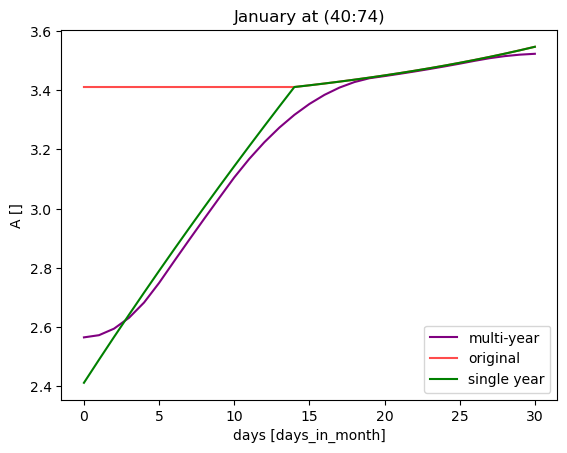

In [21]:
smoothed = xr.open_dataset('/home/miriamn/CHAZ/CHAZvectorized/pre/testing/smoothed_A_200101.nc')
original = xr.open_dataset('/home/miriamn/CHAZ/CHAZvectorized/pre/testing/v1_A_200101.nc')
single_year = xr.open_dataset('/home/miriamn/CHAZ/CHAZvectorized/pre/testing/v3_A_200101.nc')

lat = 40
lon = 74

smoothed.sel(Adim = 1, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'purple', label = 'multi-year')#label="multi-year, Adim = 1")
original.sel(Adim = 1, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'red',alpha = 0.7, label = 'original')#label="original, Adim = 1")
single_year.sel(Adim = 1, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'green', label = 'single year')#label="single-year, Adim = 1")

plt.legend()
plt.title(f'January at ({lat}:{lon})')


Text(0.5, 1.0, 'August at (40:74)')

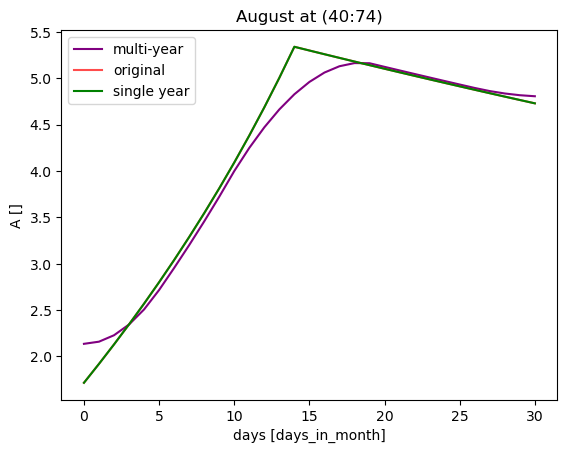

In [22]:
smoothed = xr.open_dataset('/home/miriamn/CHAZ/CHAZvectorized/pre/testing/smoothed_A_200108.nc')
original = xr.open_dataset('/home/miriamn/CHAZ/CHAZvectorized/pre/testing/v1_A_200108.nc')
single_year = xr.open_dataset('/home/miriamn/CHAZ/CHAZvectorized/pre/testing/v3_A_200108.nc')

lat = 40
lon = 74

smoothed.sel(Adim = 1, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'purple', label = 'multi-year')#label="multi-year, Adim = 1")
original.sel(Adim = 1, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'red',alpha = 0.7, label = 'original')#label="original, Adim = 1")
single_year.sel(Adim = 1, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'green', label = 'single year')#label="single-year, Adim = 1")

plt.legend()
plt.title(f'August at ({lat}:{lon})')

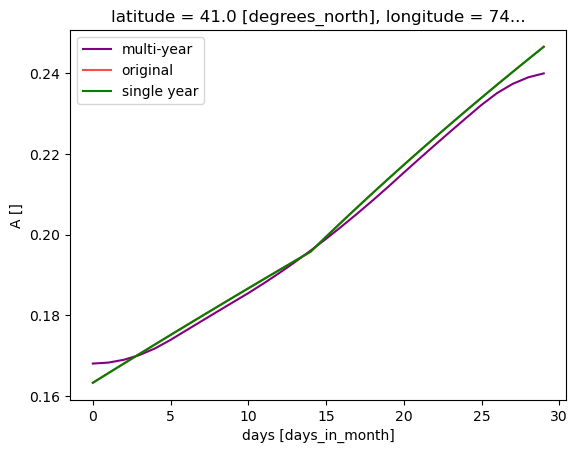

In [24]:
smoothed = xr.open_dataset('/home/miriamn/CHAZ/CHAZvectorized/pre/testing/smoothed_A_200109.nc')
original = xr.open_dataset('/home/miriamn/CHAZ/CHAZvectorized/pre/testing/v1_A_200109.nc')
single_year = xr.open_dataset('/home/miriamn/CHAZ/CHAZvectorized/pre/testing/v3_A_200109.nc')

lat = 40
lon = 74

smoothed.sel(Adim = 3, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'purple', label = 'multi-year')#label="multi-year, Adim = 1")
original.sel(Adim = 3, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'red',alpha = 0.7, label = 'original')#label="original, Adim = 1")
single_year.sel(Adim = 3, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'green', label = 'single year')#label="single-year, Adim = 1")

plt.legend()
#plt.title(f'August at ({lat}:{lon})')

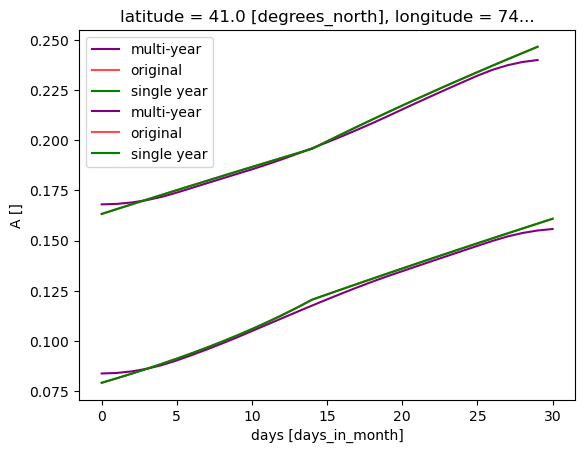

In [ ]:
smoothed = xr.open_dataset('/home/miriamn/CHAZ/CHAZvectorized/pre/testing/smoothed_A_200109.nc')
original = xr.open_dataset('/home/miriamn/CHAZ/CHAZvectorized/pre/testing/v1_A_200109.nc')
single_year = xr.open_dataset('/home/miriamn/CHAZ/CHAZvectorized/pre/testing/v3_A_200109.nc')

lat = 40
lon = 74

smoothed.sel(Adim = 3, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'purple', label = 'multi-year')#label="multi-year, Adim = 1")
original.sel(Adim = 3, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'red',alpha = 0.7, label = 'original')#label="original, Adim = 1")
single_year.sel(Adim = 3, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'green', label = 'single year')#label="single-year, Adim = 1")

plt.legend()
#plt.title(f'August at ({lat}:{lon})')

smoothed = xr.open_dataset('/home/miriamn/CHAZ/CHAZvectorized/pre/testing/smoothed_A_200108.nc')
original = xr.open_dataset('/home/miriamn/CHAZ/CHAZvectorized/pre/testing/v1_A_200108.nc')
single_year = xr.open_dataset('/home/miriamn/CHAZ/CHAZvectorized/pre/testing/v3_A_200108.nc')

lat = 40
lon = 74

smoothed.sel(Adim = 3, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'purple', label = 'multi-year')#label="multi-year, Adim = 1")
original.sel(Adim = 3, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'red',alpha = 0.7, label = 'original')#label="original, Adim = 1")
single_year.sel(Adim = 3, latitude=lat, longitude=lon, method="nearest").A.plot(color = 'green', label = 'single year')#label="single-year, Adim = 1")

plt.legend()
#plt.title(f'August at ({lat}:{lon})')

In [12]:
A1

array([[[[ 9.18142985e+00,  9.03445859e+00,  8.88505655e+00, ...,
           5.46385893e+00,  5.35182634e+00,  5.23739782e+00],
         [ 9.19711063e+00,  9.04709304e+00,  8.89454557e+00, ...,
           5.42878570e+00,  5.31712993e+00,  5.20307862e+00],
         [ 9.20899682e+00,  9.05626030e+00,  8.90090326e+00, ...,
           5.40032040e+00,  5.28949828e+00,  5.17630406e+00],
         ...,
         [ 9.11322346e+00,  8.97741828e+00,  8.83952691e+00, ...,
           5.60952234e+00,  5.49899674e+00,  5.38620361e+00],
         [ 9.13949624e+00,  8.99961150e+00,  8.85751787e+00, ...,
           5.55442070e+00,  5.44299568e+00,  5.32924147e+00],
         [ 9.16231831e+00,  9.01871131e+00,  8.87278032e+00, ...,
           5.50572419e+00,  5.39377836e+00,  5.27945936e+00]],

        [[ 9.18142985e+00,  9.03445859e+00,  8.88505655e+00, ...,
           5.46385893e+00,  5.35182634e+00,  5.23739782e+00],
         [ 9.19711063e+00,  9.04709304e+00,  8.89454557e+00, ...,
           5.42878570e